In [182]:
# imports, seed setup, and device check
import os
import re
import random
import math
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from transformers import BertTokenizer
from transformers import get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [183]:
# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # make training more stable (slightly slower)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [184]:
# device

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", DEVICE)
print("Torch version:", torch.__version__)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU memory: {total_mem:.2f} GB")
else:
    print("Running on CPU.")

Seed: 42
Device: cuda
Torch version: 2.9.0+cu126
GPU: Tesla P100-PCIE-16GB
GPU memory: 15.89 GB


# Load 20 Newsgroups, drop uplicate, 

Repo card metadata block was not found. Setting CardData to empty.


Splits: ['train', 'test']
Train size: 11314
Test size : 7532


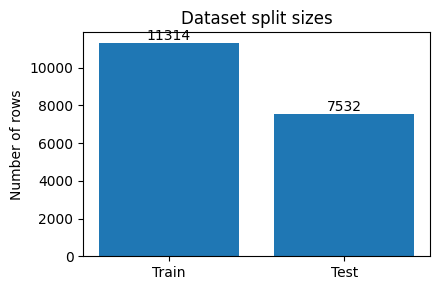

In [185]:
# Reason: load HF dataset with predefined train/test splits

ds = load_dataset("SetFit/20_newsgroups")

train_size = len(ds["train"])
test_size  = len(ds["test"])

print("Splits:", list(ds.keys()))
print("Train size:", train_size)
print("Test size :", test_size)

plt.figure(figsize=(4.5, 3))
plt.title("Dataset split sizes")
plt.bar(["Train", "Test"], [train_size, test_size])
plt.ylabel("Number of rows")
for i, v in enumerate([train_size, test_size]):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [186]:
# Reason: DataFrame makes filtering and duplicate removal simple
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])

print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

Train columns: ['text', 'label', 'label_text']
Test columns : ['text', 'label', 'label_text']


Missing columns in train: set()
Schema check passed.


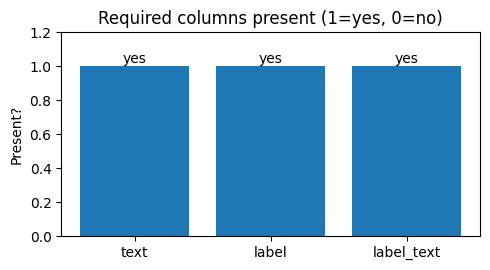

In [187]:
# Reason: fail early if dataset structure changes

required = {"text", "label", "label_text"}
present = set(train_df.columns)

check_names = ["text", "label", "label_text"]
check_vals = [1 if c in present else 0 for c in check_names]

missing = required - present
print("Missing columns in train:", missing)
assert not missing, "Missing required columns"
print("Schema check passed.")

plt.figure(figsize=(5, 2.8))
plt.title("Required columns present (1=yes, 0=no)")
plt.bar(check_names, check_vals)
plt.ylim(0, 1.2)
plt.ylabel("Present?")
for i, v in enumerate(check_vals):
    plt.text(i, v, "yes" if v == 1 else "no", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Empty removed:
  Train: 11314 -> 11014 | removed: 300
  Test : 7532 -> 7317 | removed: 215


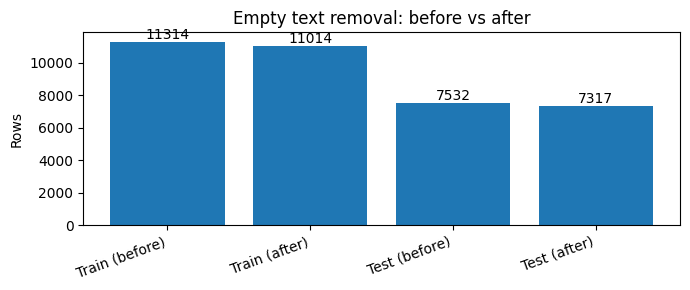

In [188]:
# Reason: empty texts provide no learning signal

before_train = len(train_df)
before_test  = len(test_df)

train_df = train_df[train_df["text"].astype(str).str.strip() != ""].reset_index(drop=True)
test_df  = test_df[test_df["text"].astype(str).str.strip() != ""].reset_index(drop=True)

after_train = len(train_df)
after_test  = len(test_df)

print("Empty removed:")
print("  Train:", before_train, "->", after_train, "| removed:", before_train - after_train)
print("  Test :", before_test,  "->", after_test,  "| removed:", before_test  - after_test)

labels = ["Train (before)", "Train (after)", "Test (before)", "Test (after)"]
vals   = [before_train, after_train, before_test, after_test]

plt.figure(figsize=(7, 3))
plt.title("Empty text removal: before vs after")
plt.bar(labels, vals)
plt.ylabel("Rows")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(vals):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [189]:
#remove duplicates
remove_train_duplicates = True
remove_test_duplicates = False

# Reason: duplicates can bias training

if remove_train_duplicates:
    before = len(train_df)
    train_df = train_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    print("Train duplicates removed:", before - len(train_df))
else:
    print("Train duplicate removal skipped.")

if remove_test_duplicates:
    before = len(test_df)
    test_df = test_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    print("Test duplicates removed:", before - len(test_df))
else:
    print("Test duplicate removal skipped.")

Train duplicates removed: 33
Test duplicate removal skipped.


Number of classes: 20
First few mappings:
0 -> alt.atheism
1 -> comp.graphics
2 -> comp.os.ms-windows.misc
3 -> comp.sys.ibm.pc.hardware
4 -> comp.sys.mac.hardware


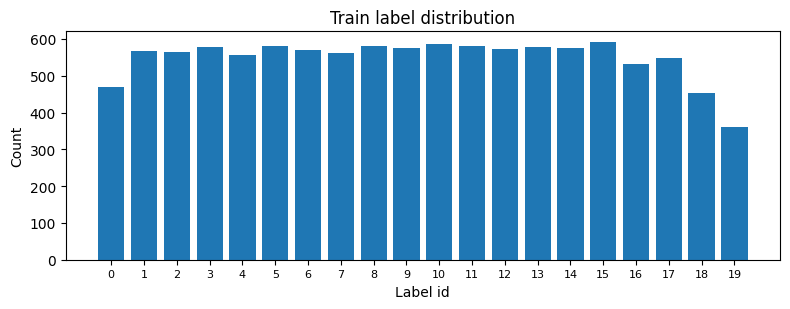

In [190]:
# Reason: makes numeric labels human-readable

id2label = {}
for lid, name in zip(train_df["label"], train_df["label_text"]):
    if lid not in id2label:
        id2label[lid] = name

label2id = {v: k for k, v in id2label.items()}

print("Number of classes:", len(id2label))
print("First few mappings:")
for k in sorted(id2label)[:5]:
    print(k, "->", id2label[k])

label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(8, 3.2))
plt.title("Train label distribution")
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Label id")
plt.ylabel("Count")

# make x-axis readable: show every 1 label, but keep them small
plt.xticks(label_counts.index, fontsize=8)
plt.tight_layout()
plt.show()

In [191]:
# Reason: cleaning must not remove any class completely

print("Train unique labels:", sorted(train_df["label"].unique()))
print("Test unique labels :", sorted(test_df["label"].unique()))

assert sorted(train_df["label"].unique()) == list(range(20)), "Train lost some labels"
assert sorted(test_df["label"].unique()) == list(range(20)), "Test lost some labels"

print("Label coverage OK.")

Train unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Test unique labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Label coverage OK.


Final sizes:
Train: 10981
Test : 7317


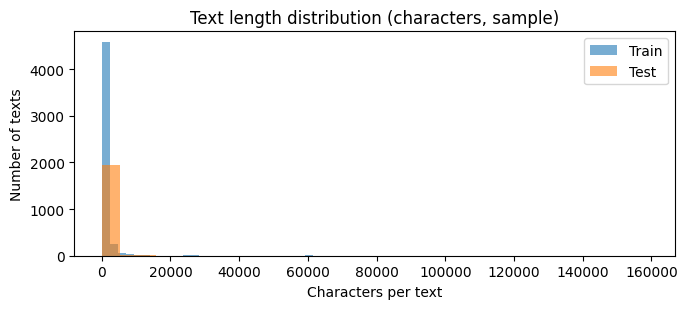

In [192]:
# Reason: return lists for training pipeline

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()
train_label_texts = train_df["label_text"].tolist()

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()
test_label_texts = test_df["label_text"].tolist()

print("Final sizes:")
print("Train:", len(train_texts))
print("Test :", len(test_texts))

# Use a sample so the histogram is fast + readable
train_lens = [len(t) for t in train_texts[:5000]]
test_lens  = [len(t) for t in test_texts[:2000]]

plt.figure(figsize=(7, 3.2))
plt.title("Text length distribution (characters, sample)")
plt.hist(train_lens, bins=30, alpha=0.6, label="Train")
plt.hist(test_lens, bins=30, alpha=0.6, label="Test")
plt.xlabel("Characters per text")
plt.ylabel("Number of texts")
plt.legend()
plt.tight_layout()
plt.show()

# **Minimal cleaning + tokenizer inspection**

Raw (first 200 chars):
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were 

Cleaned (first 200 chars):
I was wondering if anyone out there could enlighten me on this car I saw the other day. It was a 2-door sports car, looked to be from the late 60s/ early 70s. It was called a Bricklin. The doors were 


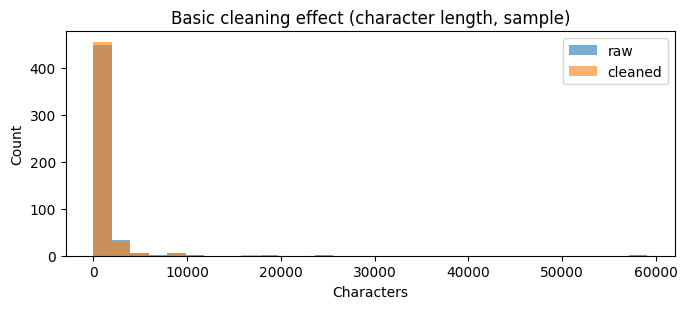

In [193]:
# basic cleaning (light only)
_control_char_re = re.compile(r"[\x00-\x1F\x7F]")

def clean_text_basic(text):
    if not isinstance(text, str):
        return ""
    text = _control_char_re.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

assert "train_texts" in globals(), "Run Section 2 first."

raw_example = train_texts[0]
clean_example = clean_text_basic(raw_example)

print("Raw (first 200 chars):")
print(raw_example[:200])
print("\nCleaned (first 200 chars):")
print(clean_example[:200])

# simple visual: compare character lengths (raw vs cleaned) on a small sample
sample_n = 500
raw_lens = [len(str(t)) for t in train_texts[:sample_n]]
clean_lens = [len(clean_text_basic(t)) for t in train_texts[:sample_n]]

plt.figure(figsize=(7, 3.2))
plt.title("Basic cleaning effect (character length, sample)")
plt.hist(raw_lens, bins=30, alpha=0.6, label="raw")
plt.hist(clean_lens, bins=30, alpha=0.6, label="cleaned")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Loaded tokenizer: bert-base-uncased
Vocab size: 30522
Model max length: 512
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


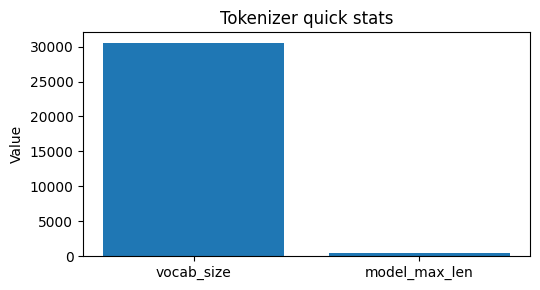

In [194]:
#Load tokenizer + inspect basics
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Loaded tokenizer:", MODEL_NAME)
print("Vocab size:", tokenizer.vocab_size)
print("Model max length:", tokenizer.model_max_length)
print("Special tokens:", tokenizer.special_tokens_map)

# visual: tiny bar chart for two key numbers (just for report screenshots)
plt.figure(figsize=(5.5, 3))
plt.title("Tokenizer quick stats")
plt.bar(["vocab_size", "model_max_len"], [tokenizer.vocab_size, tokenizer.model_max_length])
plt.ylabel("Value")
plt.tight_layout()
plt.show()

Tokenized length: 64
Tokens:
['[CLS]', 'i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'en', '##light', '##en', 'me', 'on', 'this', 'car', 'i', 'saw', 'the', 'other', 'day', '.', 'it', 'was', 'a', '2', '-', 'door', 'sports', 'car', ',', 'looked', 'to', 'be', 'from', 'the', 'late', '60s', '/', 'early', '70s', '.', 'it', 'was', 'called', 'a', 'brick', '##lin', '.', 'the', 'doors', 'were', 'really', 'small', '.', 'in', 'addition', ',', 'the', 'front', 'bumper', 'was', 'separate', '[SEP]']

Decoded (with specials):
[CLS] i was wondering if anyone out there could enlighten me on this car i saw the other day. it was a 2 - door sports car, looked to be from the late 60s / early 70s. it was called a bricklin. the doors were really small. in addition, the front bump

Decoded (no specials):
i was wondering if anyone out there could enlighten me on this car i saw the other day. it was a 2 - door sports car, looked to be from the late 60s / early 70s. it was called a bricklin. th

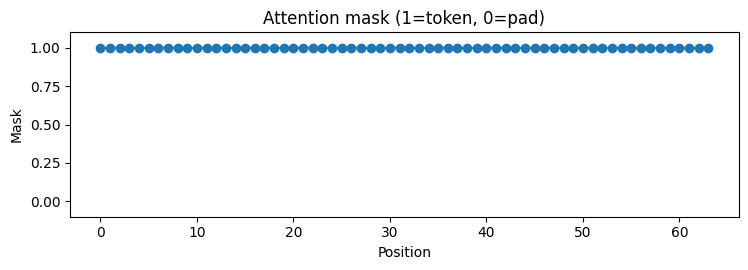

In [195]:
# Tokenize 1 example
assert "train_texts" in globals(), "Run Section 2 first."

DISPLAY_MAX_LEN = 64

raw_text = train_texts[0]
clean_text = clean_text_basic(raw_text)

enc = tokenizer(
    clean_text,
    truncation=True,
    max_length=DISPLAY_MAX_LEN,
    padding="max_length",
    return_tensors="pt"
)

input_ids = enc["input_ids"][0]
attention_mask = enc["attention_mask"][0]
tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())

print("Tokenized length:", int(input_ids.shape[0]))
print("Tokens:")
print(tokens)

print("\nDecoded (with specials):")
print(tokenizer.decode(input_ids, skip_special_tokens=False)[:250])

print("\nDecoded (no specials):")
print(tokenizer.decode(input_ids, skip_special_tokens=True)[:250])

# visual: attention mask across positions (1 means real token, 0 means padding)
plt.figure(figsize=(7.5, 2.8))
plt.title("Attention mask (1=token, 0=pad)")
plt.plot(attention_mask.tolist(), marker="o")
plt.ylim(-0.1, 1.1)
plt.xlabel("Position")
plt.ylabel("Mask")
plt.tight_layout()
plt.show()

Token indices sequence length is longer than the specified maximum sequence length for this model (604 > 512). Running this sequence through the model will result in indexing errors


Token length stats (train sample):
  mean: 395.5
  p95 : 801
  max : 51937


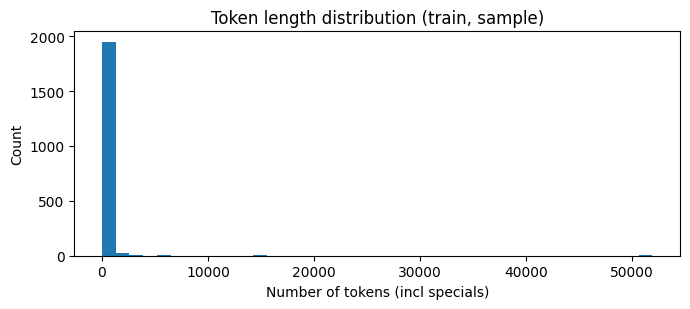

In [196]:
#Token length distribution
# quick token length distribution for the cleaned texts (sampled for speed)
sample_n = 2000
lens = []
for t in train_texts[:sample_n]:
    t = clean_text_basic(t)
    ids = tokenizer(t, add_special_tokens=True, truncation=False)["input_ids"]
    lens.append(len(ids))

lens = np.array(lens)

print("Token length stats (train sample):")
print("  mean:", round(float(lens.mean()), 1))
print("  p95 :", int(np.percentile(lens, 95)))
print("  max :", int(lens.max()))

plt.figure(figsize=(7, 3.2))
plt.title("Token length distribution (train, sample)")
plt.hist(lens, bins=40)
plt.xlabel("Number of tokens (incl specials)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

   max_len  truncated_%  mean_len  p95_len  max_observed  split
0      256        24.07     273.0      745         15821   test
1      384        13.20     273.0      745         15821   test
2      512         7.67     273.0      745         15821   test
3      256        24.67     356.7      807         51937  train
4      384        13.77     356.7      807         51937  train
5      512         9.23     356.7      807         51937  train


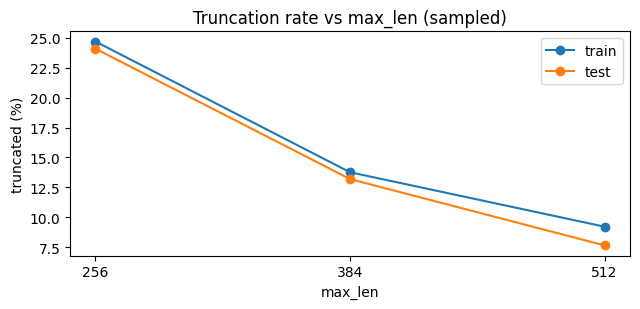

In [197]:
#Truncation analysis function + table
def measure_truncation(tokenizer, texts, max_len, sample_n=None):
    lengths = []
    use_texts = texts if sample_n is None else texts[:sample_n]

    for t in use_texts:
        t = clean_text_basic(t)
        enc = tokenizer(t, add_special_tokens=True, truncation=False)
        lengths.append(len(enc["input_ids"]))

    lengths = np.array(lengths)
    return {
        "max_len": max_len,
        "truncated_%": round(float((lengths > max_len).mean() * 100), 2),
        "mean_len": round(float(lengths.mean()), 1),
        "p95_len": int(np.percentile(lengths, 95)),
        "max_observed": int(lengths.max())
    }

assert "test_texts" in globals(), "Run Section 2 first."

rows = []
for L in [256, 384, 512]:
    r_train = measure_truncation(tokenizer, train_texts, L, sample_n=3000)
    r_train["split"] = "train"
    rows.append(r_train)

    r_test = measure_truncation(tokenizer, test_texts, L, sample_n=1500)
    r_test["split"] = "test"
    rows.append(r_test)

df_trunc = pd.DataFrame(rows).sort_values(["split", "max_len"]).reset_index(drop=True)
print(df_trunc)

# visual: truncated_% vs max_len for train/test
plt.figure(figsize=(6.5, 3.2))
plt.title("Truncation rate vs max_len (sampled)")
for split in ["train", "test"]:
    sub = df_trunc[df_trunc["split"] == split]
    plt.plot(sub["max_len"], sub["truncated_%"], marker="o", label=split)

plt.xlabel("max_len")
plt.ylabel("truncated (%)")
plt.xticks([256, 384, 512])
plt.legend()
plt.tight_layout()
plt.show()

Long example index: 2


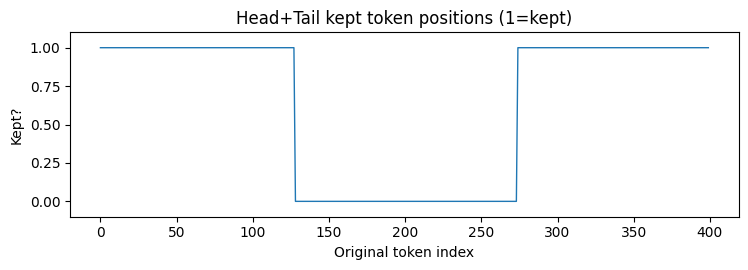

In [198]:
#Head+Tail encoding demo helpers

def encode_head_tail_demo(tokenizer, text, max_len=256, head_len=128):
    text = clean_text_basic(text)
    ids = tokenizer.encode(text, add_special_tokens=False)

    budget = max_len - 2  # for [CLS] and [SEP]

    if len(ids) <= budget:
        kept = ids
        kept_positions = list(range(len(ids)))
    else:
        tail_len = budget - head_len
        kept = ids[:head_len] + ids[-tail_len:]
        kept_positions = list(range(head_len)) + list(range(len(ids) - tail_len, len(ids)))

    final_ids = [tokenizer.cls_token_id] + kept + [tokenizer.sep_token_id]

    pad_id = tokenizer.pad_token_id or 0
    if len(final_ids) < max_len:
        final_ids += [pad_id] * (max_len - len(final_ids))

    mask = [0 if x == pad_id else 1 for x in final_ids]

    return torch.tensor(final_ids), torch.tensor(mask), ids, kept_positions


def find_long_example(texts, threshold=256):
    for i, t in enumerate(texts):
        t_clean = clean_text_basic(t)
        enc = tokenizer(t_clean, add_special_tokens=True, truncation=False)
        if len(enc["input_ids"]) > threshold:
            return i, t
    return None, None


idx, long_text = find_long_example(train_texts, threshold=256)
print("Long example index:", idx)

# visual: show which original token positions are kept (head+tail)
if long_text:
    _, _, orig_ids, kept_positions = encode_head_tail_demo(tokenizer, long_text, max_len=256, head_len=128)

    indicator = np.zeros(len(orig_ids), dtype=int)
    indicator[kept_positions] = 1

    plt.figure(figsize=(7.5, 2.8))
    plt.title("Head+Tail kept token positions (1=kept)")
    plt.plot(indicator, linewidth=1)
    plt.ylim(-0.1, 1.1)
    plt.xlabel("Original token index")
    plt.ylabel("Kept?")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(5, 2.5))
    plt.title("Head+Tail demo")
    plt.text(0.1, 0.5, "No long example found in current data", fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


Head-only end snippet:
k rather than the 120, but i don ' t really have a feel for how much " better " the display is ( yea, it looks great in the store, but is that all " wow " or is it really that good? ). could i solicit

Head+Tail end snippet:
 - if you could email, i ' ll post a summary ( news reading time is at a premium with finals just around the corner... : ( ) - - tom willis \ twillis @ ecn. purdue. edu \ purdue electrical engineering


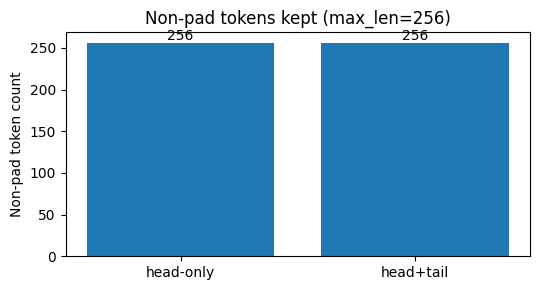

In [199]:
#Compare head-only vs head+tail
if long_text:
    long_clean = clean_text_basic(long_text)

    head_only_ids = tokenizer(
        long_clean,
        truncation=True,
        max_length=256,
        padding="max_length"
    )["input_ids"]

    head_tail_ids, head_tail_mask, _, _ = encode_head_tail_demo(tokenizer, long_clean, 256, 128)

    head_only_decoded_end = tokenizer.decode(head_only_ids, skip_special_tokens=True)[-200:]
    head_tail_decoded_end = tokenizer.decode(head_tail_ids, skip_special_tokens=True)[-200:]

    print("\nHead-only end snippet:")
    print(head_only_decoded_end)

    print("\nHead+Tail end snippet:")
    print(head_tail_decoded_end)

    # visual: compare how many non-pad tokens each strategy keeps (should be similar, but shown clearly)
    head_only_nonpad = int(sum([1 for x in head_only_ids if x != (tokenizer.pad_token_id or 0)]))
    head_tail_nonpad = int(head_tail_mask.sum().item())

    plt.figure(figsize=(5.5, 3))
    plt.title("Non-pad tokens kept (max_len=256)")
    plt.bar(["head-only", "head+tail"], [head_only_nonpad, head_tail_nonpad])
    plt.ylabel("Non-pad token count")
    for i, v in enumerate([head_only_nonpad, head_tail_nonpad]):
        plt.text(i, v, str(v), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(5, 2.5))
    plt.title("Head-only vs Head+Tail")
    plt.text(0.1, 0.5, "Skipped (no long example found)", fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Section 3 done.
MAX_LEN = 256
TOKENIZE_STRATEGY = head_tail


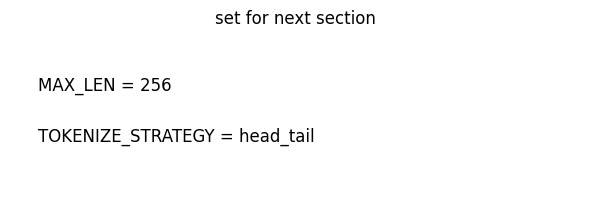

In [200]:
# what we choose
MAX_LEN = 256
TOKENIZE_STRATEGY = "head_tail"

print("Section 3 done.")
print("MAX_LEN =", MAX_LEN)
print("TOKENIZE_STRATEGY =", TOKENIZE_STRATEGY)

# visual: simple config “card”
plt.figure(figsize=(6, 2.2))
plt.title("set for next section")
plt.text(0.05, 0.65, f"MAX_LEN = {MAX_LEN}", fontsize=12)
plt.text(0.05, 0.35, f"TOKENIZE_STRATEGY = {TOKENIZE_STRATEGY}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

# Train/Val split + Dataset + Bucketed DataLoaders

In [201]:
#Basic checks + quick dataset-size visual
required = [
    "train_texts", "train_labels",
    "test_texts", "test_labels",
    "tokenizer", "clean_text_basic",
    "MAX_LEN", "TOKENIZE_STRATEGY"
]
for r in required:
    assert r in globals(), f"{r} not found. Run previous sections."

print("Train size:", len(train_texts))
print("Test size :", len(test_texts))
print("Max length:", MAX_LEN)
print("Strategy  :", TOKENIZE_STRATEGY)

Train size: 10981
Test size : 7317
Max length: 256
Strategy  : head_tail


Train split: 9333
Val split  : 1648


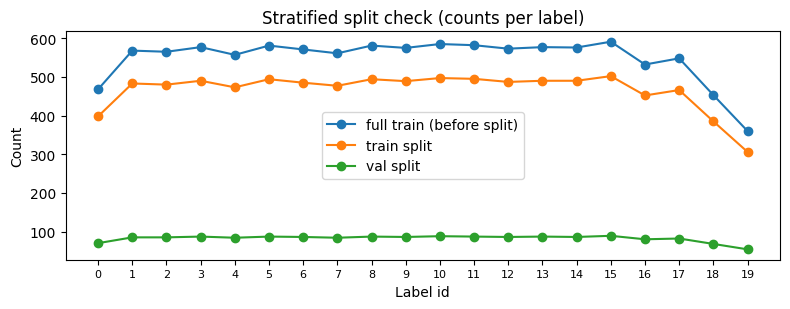

In [202]:
#Train/Val split (stratified) + label distribution
VAL_RATIO = 0.15
RANDOM_SEED = 42

all_indices = np.arange(len(train_texts))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VAL_RATIO,
    random_state=RANDOM_SEED,
    stratify=np.array(train_labels)
)

print("Train split:", len(train_indices))
print("Val split  :", len(val_indices))

# visual: label distribution before vs after split (train only)
train_labels_arr = np.array(train_labels)

full_counts = np.bincount(train_labels_arr, minlength=20)
train_counts = np.bincount(train_labels_arr[train_indices], minlength=20)
val_counts   = np.bincount(train_labels_arr[val_indices], minlength=20)

plt.figure(figsize=(8, 3.2))
plt.title("Stratified split check (counts per label)")
x = np.arange(20)
plt.plot(x, full_counts, marker="o", label="full train (before split)")
plt.plot(x, train_counts, marker="o", label="train split")
plt.plot(x, val_counts, marker="o", label="val split")
plt.xlabel("Label id")
plt.ylabel("Count")
plt.xticks(x, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

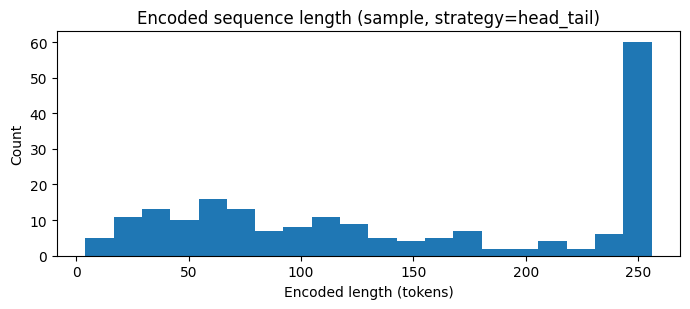

Encoded length min/mean/max: 4 145.2 256


In [203]:
#Encoding function (no padding) + 1 example visual
def encode_text(text):
    text = clean_text_basic(text)

    # standard head-only truncation
    if TOKENIZE_STRATEGY == "head_only":
        enc = tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding=False,
            return_tensors="pt"
        )
        ids = enc["input_ids"].squeeze(0)
        mask = enc["attention_mask"].squeeze(0)
        return ids, mask

    # head + tail truncation
    token_ids = tokenizer.encode(text, add_special_tokens=False)

    budget = MAX_LEN - 2
    head_len = budget // 2
    tail_len = budget - head_len

    if len(token_ids) > budget:
        token_ids = token_ids[:head_len] + token_ids[-tail_len:]

    token_ids = [tokenizer.cls_token_id] + token_ids + [tokenizer.sep_token_id]
    mask = [1] * len(token_ids)

    return torch.tensor(token_ids), torch.tensor(mask)


# visual: show encoded length for a few examples
sample_n = 200
lens = []
for t in train_texts[:sample_n]:
    ids, _ = encode_text(t)
    lens.append(int(ids.shape[0]))

plt.figure(figsize=(7, 3.2))
plt.title(f"Encoded sequence length (sample, strategy={TOKENIZE_STRATEGY})")
plt.hist(lens, bins=20)
plt.xlabel("Encoded length (tokens)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Encoded length min/mean/max:", min(lens), round(sum(lens)/len(lens), 1), max(lens))

Datasets created: 9333 (train) 1648 (val) 7317 (test)


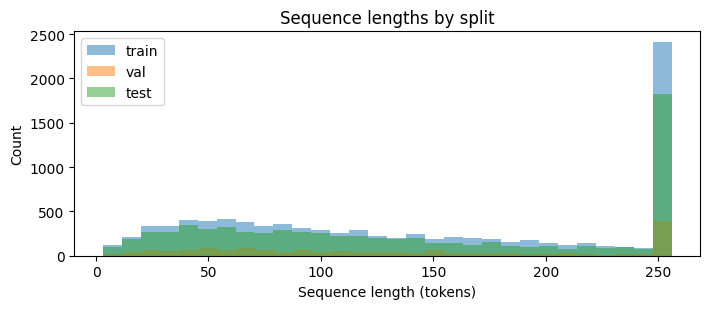

In [204]:
#Dataset class + create dataset objects
class TextDataset(Dataset):
    def __init__(self, texts, labels, indices):
        self.texts = texts
        self.labels = labels
        self.indices = np.array(indices)
        self._cached_lengths = None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_index = int(self.indices[i])
        ids, mask = encode_text(self.texts[real_index])
        label = torch.tensor(int(self.labels[real_index]))
        return {"input_ids": ids, "attention_mask": mask, "labels": label}

    def get_lengths(self):
        if self._cached_lengths is None:
            lengths = []
            for i in range(len(self)):
                lengths.append(len(self[i]["input_ids"]))
            self._cached_lengths = np.array(lengths)
        return self._cached_lengths


train_dataset = TextDataset(train_texts, train_labels, train_indices)
val_dataset   = TextDataset(train_texts, train_labels, val_indices)
test_dataset  = TextDataset(test_texts,  test_labels,  np.arange(len(test_texts)))

print("Datasets created:",
      len(train_dataset), "(train)",
      len(val_dataset), "(val)",
      len(test_dataset), "(test)")

# visual: compare sequence length distributions
train_l = train_dataset.get_lengths()
val_l   = val_dataset.get_lengths()
test_l  = test_dataset.get_lengths()

plt.figure(figsize=(7.2, 3.2))
plt.title("Sequence lengths by split")
plt.hist(train_l, bins=30, alpha=0.5, label="train")
plt.hist(val_l, bins=30, alpha=0.5, label="val")
plt.hist(test_l, bins=30, alpha=0.5, label="test")
plt.xlabel("Sequence length (tokens)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

PAD_ID: 0
Demo batch shape: (16, 256)
Real tokens: 2570 | Pad tokens: 1526


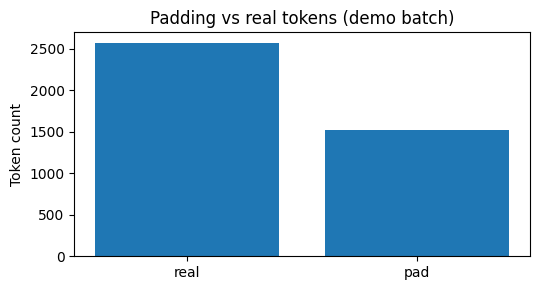

In [205]:
#Dynamic padding collate
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

def dynamic_collate(batch):
    ids = [item["input_ids"] for item in batch]
    masks = [item["attention_mask"] for item in batch]

    ids = torch.nn.utils.rnn.pad_sequence(ids, batch_first=True, padding_value=PAD_ID)
    masks = torch.nn.utils.rnn.pad_sequence(masks, batch_first=True, padding_value=0)

    labels = torch.stack([item["labels"] for item in batch])

    return {"input_ids": ids, "attention_mask": masks, "labels": labels}

print("PAD_ID:", PAD_ID)

# visual idea: show padding fraction for a random mini-batch from train_dataset (not using DataLoader yet)
batch_size_demo = 16
demo_idx = np.random.choice(len(train_dataset), size=batch_size_demo, replace=False)
demo_batch = [train_dataset[i] for i in demo_idx]
demo_collated = dynamic_collate(demo_batch)

ids = demo_collated["input_ids"]
mask = demo_collated["attention_mask"]

total_tokens = ids.numel()
real_tokens = int(mask.sum().item())
pad_tokens = total_tokens - real_tokens

print("Demo batch shape:", tuple(ids.shape))
print("Real tokens:", real_tokens, "| Pad tokens:", pad_tokens)

plt.figure(figsize=(5.5, 3))
plt.title("Padding vs real tokens (demo batch)")
plt.bar(["real", "pad"], [real_tokens, pad_tokens])
plt.ylabel("Token count")
plt.tight_layout()
plt.show()

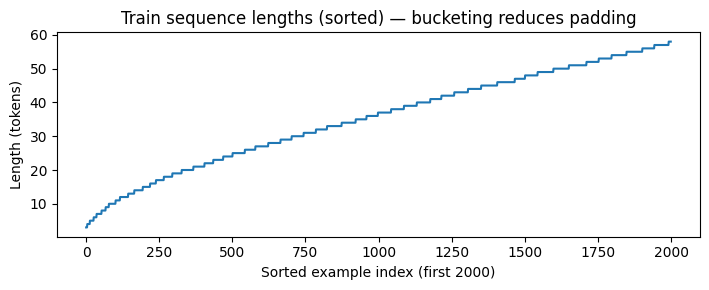

In [206]:
#BucketSampler
class BucketSampler(torch.utils.data.Sampler):
    def __init__(self, lengths, batch_size, shuffle_batches):
        order = np.argsort(lengths)
        self.order = order.tolist()
        self.batch_size = batch_size
        self.shuffle_batches = shuffle_batches

    def __iter__(self):
        batches = [self.order[i:i+self.batch_size]
                   for i in range(0, len(self.order), self.batch_size)]
        if self.shuffle_batches:
            random.shuffle(batches)
        for batch in batches:
            yield batch

    def __len__(self):
        return (len(self.order) + self.batch_size - 1) // self.batch_size


BATCH_SIZE = 16

# visual: show lengths sorted (first part of train only)
sorted_lengths = np.sort(train_dataset.get_lengths())
plt.figure(figsize=(7.2, 3))
plt.title("Train sequence lengths (sorted) — bucketing reduces padding")
plt.plot(sorted_lengths[:2000])
plt.xlabel("Sorted example index (first 2000)")
plt.ylabel("Length (tokens)")
plt.tight_layout()
plt.show()

Number of batches: 584 (train) 103 (val) 458 (test)


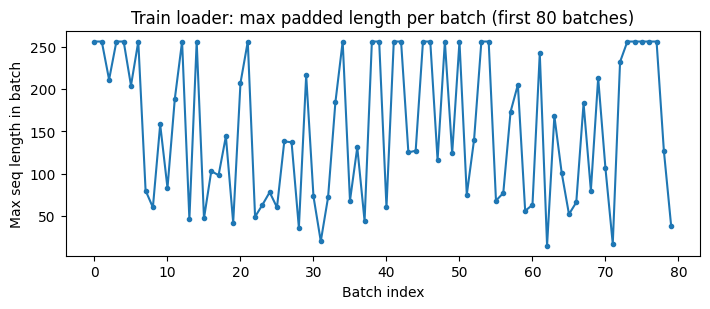

In [207]:
#Build DataLoaders +  batch max lengths
train_sampler = BucketSampler(train_dataset.get_lengths(), BATCH_SIZE, True)
val_sampler   = BucketSampler(val_dataset.get_lengths(),   BATCH_SIZE, False)
test_sampler  = BucketSampler(test_dataset.get_lengths(),  BATCH_SIZE, False)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, collate_fn=dynamic_collate)
val_loader   = DataLoader(val_dataset,   batch_sampler=val_sampler,   collate_fn=dynamic_collate)
test_loader  = DataLoader(test_dataset,  batch_sampler=test_sampler,  collate_fn=dynamic_collate)

print("Number of batches:",
      len(train_loader), "(train)",
      len(val_loader), "(val)",
      len(test_loader), "(test)")

# visual: max sequence length per batch (first 80 batches)
batch_max = []
for i, batch in enumerate(train_loader):
    batch_max.append(int(batch["input_ids"].shape[1]))
    if i >= 79:
        break

plt.figure(figsize=(7.2, 3.2))
plt.title("Train loader: max padded length per batch (first 80 batches)")
plt.plot(batch_max, marker="o", markersize=3)
plt.xlabel("Batch index")
plt.ylabel("Max seq length in batch")
plt.tight_layout()
plt.show()

In [208]:
#Quick sanity check (sample batch shapes)
sample_batch = next(iter(train_loader))

print("Sample batch shapes:")
print("input_ids:", sample_batch["input_ids"].shape)
print("attention_mask:", sample_batch["attention_mask"].shape)
print("labels:", sample_batch["labels"].shape)

print("Section 4 finished.")

Sample batch shapes:
input_ids: torch.Size([16, 48])
attention_mask: torch.Size([16, 48])
labels: torch.Size([16])
Section 4 finished.


# Build the model

Reset done.


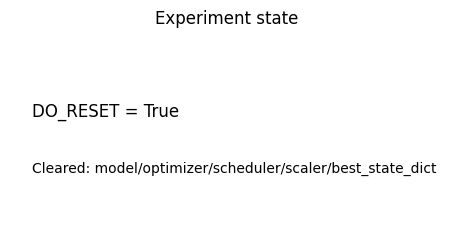

In [209]:
#reset Model
import gc
DO_RESET = True
if DO_RESET:
    for k in ["model", "optimizer", "scheduler", "scaler", "best_state_dict"]:
        if k in globals():
            del globals()[k]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Reset done.")

# tiny “status” visual (just for report screenshots)
plt.figure(figsize=(5, 2.4))
plt.title("Experiment state")
plt.text(0.05, 0.55, f"DO_RESET = {DO_RESET}", fontsize=12)
plt.text(0.05, 0.25, "Cleared: model/optimizer/scheduler/scaler/best_state_dict", fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.show()

Device: cuda
Classes: 20
Model: bert-base-uncased | pooling: mean | dropout: 0.1 | freeze: False


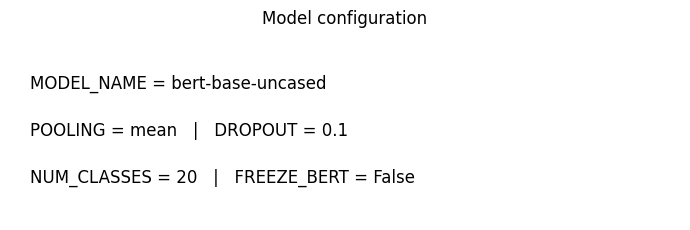

In [210]:
#checks + configuration summary
assert "DEVICE" in globals(), "Run Section 1 first (DEVICE missing)"
assert "id2label" in globals(), "Run Section 2 first (id2label missing)"
assert "tokenizer" in globals(), "Run Section 3 first (tokenizer missing)"
assert "train_loader" in globals(), "Run Section 4 first (train_loader missing)"

NUM_CLASSES = len(id2label)

MODEL_NAME = "bert-base-uncased"
POOLING = "mean"       # "cls" or "mean"
DROPOUT = 0.1
FREEZE_BERT = False

print("Device:", DEVICE)
print("Classes:", NUM_CLASSES)
print("Model:", MODEL_NAME, "| pooling:", POOLING, "| dropout:", DROPOUT, "| freeze:", FREEZE_BERT)

# visual “config card”
plt.figure(figsize=(7, 2.4))
plt.title("Model configuration")
plt.text(0.03, 0.70, f"MODEL_NAME = {MODEL_NAME}", fontsize=12)
plt.text(0.03, 0.45, f"POOLING = {POOLING}   |   DROPOUT = {DROPOUT}", fontsize=12)
plt.text(0.03, 0.20, f"NUM_CLASSES = {NUM_CLASSES}   |   FREEZE_BERT = {FREEZE_BERT}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

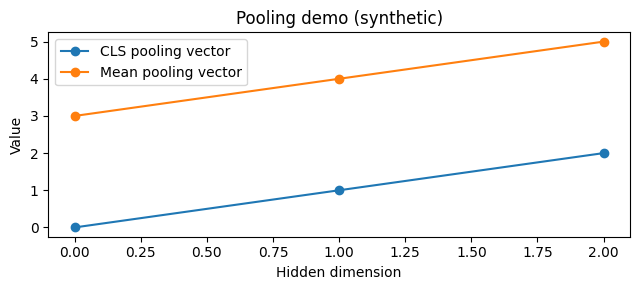

Pooling demo done (synthetic example).


In [211]:
#Pooling function + quick pooling
def pool_hidden(last_hidden, mask, mode="cls"):
    # last_hidden: [B, L, H]
    # mask: [B, L] (1 real token, 0 pad)
    mode = mode.lower()

    if mode == "cls":
        return last_hidden[:, 0]  # CLS position

    if mode == "mean":
        m = mask.unsqueeze(-1).float()            # [B, L, 1]
        summed = (last_hidden * m).sum(dim=1)     # [B, H]
        counts = m.sum(dim=1).clamp(min=1e-9)     # [B, 1]
        return summed / counts

    raise ValueError("pooling must be 'cls' or 'mean'")


# visual: demonstrate mean pooling ignores padding (tiny synthetic example)
B, L, H = 1, 6, 3
fake_hidden = torch.arange(B * L * H).float().reshape(B, L, H)
fake_mask = torch.tensor([[1, 1, 1, 0, 0, 0]])

cls_vec = pool_hidden(fake_hidden, fake_mask, mode="cls")[0].tolist()
mean_vec = pool_hidden(fake_hidden, fake_mask, mode="mean")[0].tolist()

plt.figure(figsize=(6.5, 3))
plt.title("Pooling demo (synthetic)")
plt.plot(cls_vec, marker="o", label="CLS pooling vector")
plt.plot(mean_vec, marker="o", label="Mean pooling vector")
plt.xlabel("Hidden dimension")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

print("Pooling demo done (synthetic example).")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Params: trainable=109,497,620 / total=109,497,620


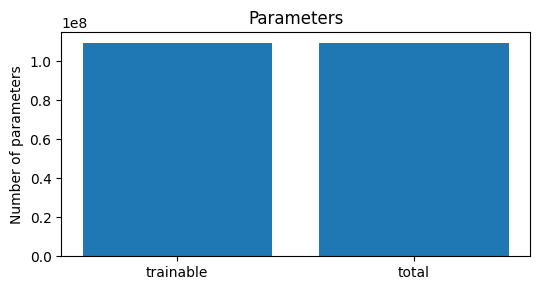

In [212]:
#Define model class + build model + parameter
class BertClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1, pooling="cls"):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.pooling = pooling
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = out.last_hidden_state
        pooled = pool_hidden(h, attention_mask, mode=self.pooling)
        pooled = self.drop(pooled)
        return self.fc(pooled)   # logits


model = BertClassifier(MODEL_NAME, NUM_CLASSES, dropout=DROPOUT, pooling=POOLING).to(DEVICE)

if FREEZE_BERT:
    for p in model.bert.parameters():
        p.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Params: trainable={trainable_params:,} / total={total_params:,}")

# visual: trainable vs total params
plt.figure(figsize=(5.5, 3))
plt.title("Parameters")
plt.bar(["trainable", "total"], [trainable_params, total_params])
plt.ylabel("Number of parameters")
plt.tight_layout()
plt.show()

Fresh check:
  logits shape: (16, 20)
  loss: 2.950005054473877
  expected around log(C): 2.995732273553991


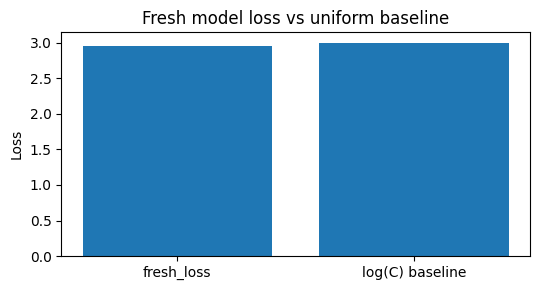

In [213]:
#Fresh sanity check (logits, loss) + loss comparison
batch = next(iter(train_loader))
x = batch["input_ids"].to(DEVICE)
m = batch["attention_mask"].to(DEVICE)
y = batch["labels"].to(DEVICE)

loss_fn = nn.CrossEntropyLoss()

model.eval()
with torch.no_grad():
    logits = model(x, m)
    loss0 = loss_fn(logits, y).item()

expected_uniform_loss = float(np.log(NUM_CLASSES))

print("Fresh check:")
print("  logits shape:", tuple(logits.shape))
print("  loss:", loss0)
print("  expected around log(C):", expected_uniform_loss)

# visual: compare fresh loss vs uniform baseline
plt.figure(figsize=(5.5, 3))
plt.title("Fresh model loss vs uniform baseline")
plt.bar(["fresh_loss", "log(C) baseline"], [loss0, expected_uniform_loss])
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

Batch info:
  batch size: 16
  padded length: 256
  real length min/mean/max: 256 256.0 256
  pad tokens: 0 | pad fraction: 0.0


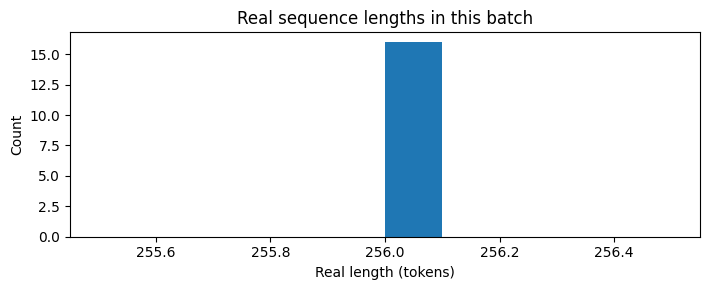

In [214]:
#Padding / length stats
B, L = x.shape
real_lens = m.sum(dim=1).detach().cpu().numpy()
pad_tokens = int(m.numel() - m.sum().item())
pad_fraction = pad_tokens / m.numel()

print("Batch info:")
print("  batch size:", B)
print("  padded length:", L)
print("  real length min/mean/max:",
      int(real_lens.min()), float(real_lens.mean()), int(real_lens.max()))
print("  pad tokens:", pad_tokens, "| pad fraction:", pad_fraction)

# visual: real lengths in the batch
plt.figure(figsize=(7.2, 3))
plt.title("Real sequence lengths in this batch")
plt.hist(real_lens, bins=10)
plt.xlabel("Real length (tokens)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Untrained confidence check:
  mean conf: 0.06564454734325409
  min/max conf: 0.06061241403222084 / 0.07164682447910309
  batch accuracy: 0.0625 | expected ~ 0.05


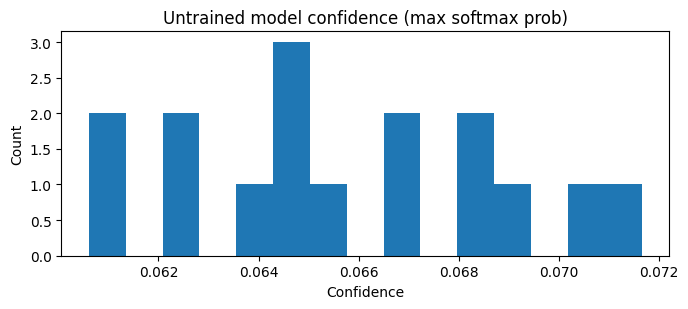

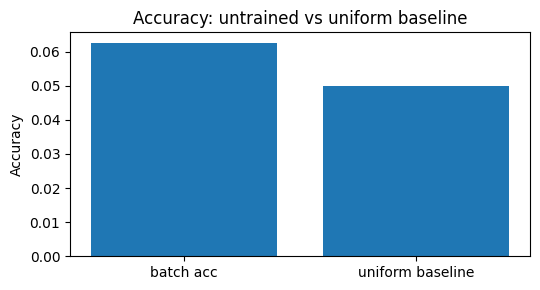

In [215]:
#Untrained confidence + accuracy
with torch.no_grad():
    probs = F.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)

acc0 = float((pred == y).float().mean().item())

print("Untrained confidence check:")
print("  mean conf:", float(conf.mean().item()))
print("  min/max conf:", float(conf.min().item()), "/", float(conf.max().item()))
print("  batch accuracy:", acc0, "| expected ~", 1.0 / NUM_CLASSES)

# visual: confidence distribution
plt.figure(figsize=(7, 3.2))
plt.title("Untrained model confidence (max softmax prob)")
plt.hist(conf.detach().cpu().numpy(), bins=15)
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# visual: accuracy vs uniform baseline
plt.figure(figsize=(5.5, 3))
plt.title("Accuracy: untrained vs uniform baseline")
plt.bar(["batch acc", "uniform baseline"], [acc0, 1.0 / NUM_CLASSES])
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

Sample 0:
  true: 2 comp.os.ms-windows.misc
  1. pred=18 talk.politics.misc        prob=0.0684
  2. pred=15 soc.religion.christian    prob=0.0626
  3. pred= 4 comp.sys.mac.hardware     prob=0.0600
  4. pred=19 talk.religion.misc        prob=0.0590
  5. pred=10 rec.sport.hockey          prob=0.0584


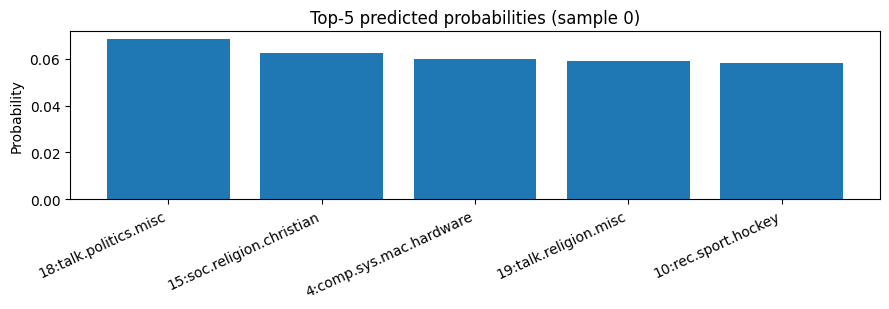

In [216]:
#Top-5 for first sample
topk = 5
tp, ti = torch.topk(probs[0], k=topk)
true0 = int(y[0].item())

print("Sample 0:")
print("  true:", true0, id2label[true0])

labels = []
values = []

for i in range(topk):
    cid = int(ti[i].item())
    p = float(tp[i].item())
    labels.append(f"{cid}:{id2label[cid]}")
    values.append(p)
    print(f"  {i+1}. pred={cid:2d} {id2label[cid]:25s} prob={p:.4f}")

plt.figure(figsize=(9, 3.2))
plt.title("Top-5 predicted probabilities (sample 0)")
plt.bar(labels, values)
plt.ylabel("Probability")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Decoded input (sample 0, no PAD):
[CLS] ok, i have a problem that i thought you guys / gals might know about.... i ' m running a 286dx - 25 with a 85mb hdd. i also have windows 3. 1, but hardly any dos application will run out it. also, when i do a " mem " command, it says that i have used up 58kb out of 640kb of conventional memory, zero from upper level memory, and all 385kb of my ems memory. and to top it off, i can ' t load any device drivers into upper memory. do i just need more memory - - - - - - - - - - - - - - - - - - - ...


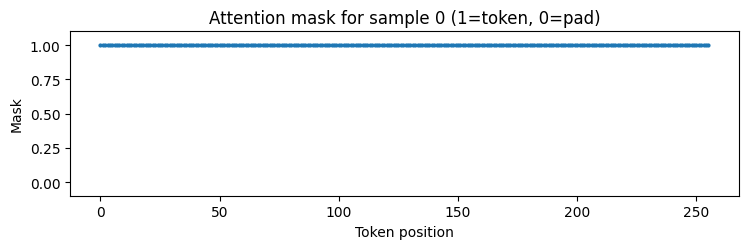

In [217]:
#Decode what model saw
ids0 = x[0].tolist()
mask0 = m[0].tolist()
ids0 = [t for t, mm in zip(ids0, mask0) if mm == 1]

print("Decoded input (sample 0, no PAD):")
print(tokenizer.decode(ids0, skip_special_tokens=False)[:500], "...")

# visual: attention mask for sample 0
plt.figure(figsize=(7.5, 2.6))
plt.title("Attention mask for sample 0 (1=token, 0=pad)")
plt.plot(m[0].detach().cpu().numpy(), marker="o", markersize=2)
plt.ylim(-0.1, 1.1)
plt.xlabel("Token position")
plt.ylabel("Mask")
plt.tight_layout()
plt.show()

Baseline reference:
  uniform acc: 0.05
  uniform loss: 2.995732273553991


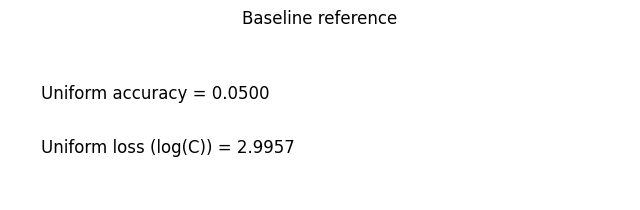

Section 5 done.


In [218]:
#Baseline reference + simple “card” visual
uniform_acc = 1.0 / NUM_CLASSES
uniform_loss = float(np.log(NUM_CLASSES))

print("Baseline reference:")
print("  uniform acc:", uniform_acc)
print("  uniform loss:", uniform_loss)

plt.figure(figsize=(6.5, 2.2))
plt.title("Baseline reference")
plt.text(0.05, 0.60, f"Uniform accuracy = {uniform_acc:.4f}", fontsize=12)
plt.text(0.05, 0.28, f"Uniform loss (log(C)) = {uniform_loss:.4f}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Section 5 done.")

# Train / Eval

Device: cuda
Train batches: 584 | Val batches: 103 | Test batches: 458


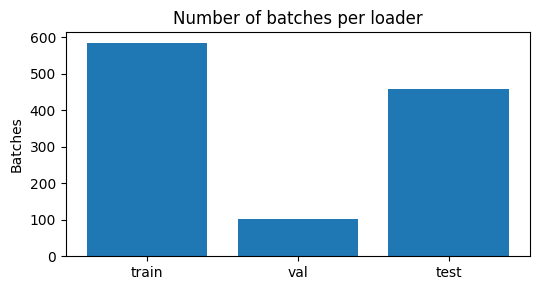

In [219]:
#Sanity checks + loader-size 
required = [
    "model",
    "train_dataset", "val_dataset", "test_dataset",
    "train_loader", "val_loader", "test_loader",
    "BucketSampler", "dynamic_collate",
    "DEVICE", "NUM_CLASSES", "id2label"
]

for name in required:
    if name not in globals():
        raise RuntimeError(f"{name} not found. Run previous sections first.")

print("Device:", DEVICE)
print("Train batches:", len(train_loader),
      "| Val batches:", len(val_loader),
      "| Test batches:", len(test_loader))

plt.figure(figsize=(5.5, 3))
plt.title("Number of batches per loader")
plt.bar(["train", "val", "test"], [len(train_loader), len(val_loader), len(test_loader)])
plt.ylabel("Batches")
plt.tight_layout()
plt.show()

train_eval_loader ready: 584 batches


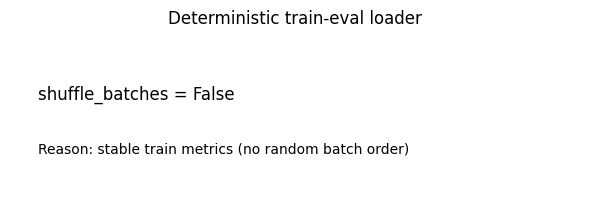

In [220]:
#Build deterministic train-eval loader + visual “shuffle off”
BATCH_SIZE = 16
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

train_eval_sampler = BucketSampler(
    train_dataset.get_lengths(),
    BATCH_SIZE,
    shuffle_batches=False
)

train_eval_loader = DataLoader(
    train_dataset,
    batch_sampler=train_eval_sampler,
    collate_fn=dynamic_collate,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("train_eval_loader ready:", len(train_eval_loader), "batches")

plt.figure(figsize=(6, 2.2))
plt.title("Deterministic train-eval loader")
plt.text(0.05, 0.60, "shuffle_batches = False", fontsize=12)
plt.text(0.05, 0.28, "Reason: stable train metrics (no random batch order)", fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.show()

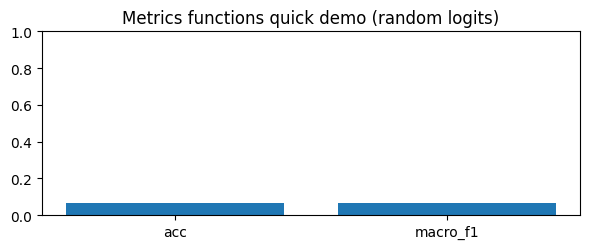

Metrics demo: acc= 0.065 macro_f1= 0.065


In [221]:
#Metrics functions + small visual demo on random logits
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return float((preds == labels).float().mean().item())

def macro_f1_from_logits(logits, labels, C):
    preds = logits.argmax(dim=1).cpu().numpy()
    y = labels.cpu().numpy()

    f1_scores = []
    for c in range(C):
        tp = ((preds == c) & (y == c)).sum()
        fp = ((preds == c) & (y != c)).sum()
        fn = ((preds != c) & (y == c)).sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 0.0 if (precision + recall == 0) else (2 * precision * recall / (precision + recall))
        f1_scores.append(f1)

    return float(np.mean(f1_scores))

def per_class_scores(logits, labels, C):
    preds = logits.argmax(dim=1).cpu().numpy()
    y = labels.cpu().numpy()

    rows = []
    for c in range(C):
        tp = ((preds == c) & (y == c)).sum()
        fp = ((preds == c) & (y != c)).sum()
        fn = ((preds != c) & (y == c)).sum()
        support = (y == c).sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 0.0 if (precision + recall == 0) else (2 * precision * recall / (precision + recall))
        rows.append((c, precision, recall, f1, support))

    rows.sort(key=lambda x: x[3])  # worst f1 first
    return rows


# visual demo: random logits (just to prove metrics run)
demo_n = 200
demo_logits = torch.randn(demo_n, NUM_CLASSES)
demo_labels = torch.randint(0, NUM_CLASSES, (demo_n,))

demo_acc = accuracy_from_logits(demo_logits, demo_labels)
demo_f1  = macro_f1_from_logits(demo_logits, demo_labels, NUM_CLASSES)

plt.figure(figsize=(6, 2.6))
plt.title("Metrics functions quick demo (random logits)")
plt.bar(["acc", "macro_f1"], [demo_acc, demo_f1])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Metrics demo:", "acc=", round(demo_acc, 4), "macro_f1=", round(demo_f1, 4))

Training setup:
epochs: 3
learning rate: 2e-05
grad accumulation: 2
optimizer steps per epoch: 292
warmup steps: 87 / 876


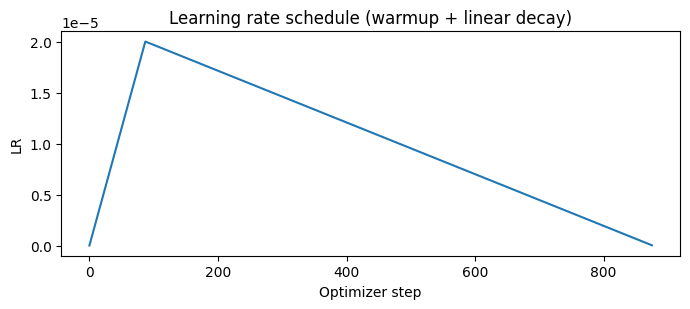

In [222]:
#Optimizer + scheduler setup + LR schedule visual
EPOCHS = 3
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
GRAD_ACCUM = 2
CLIP_NORM = 1.0

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("Training setup:")
print("epochs:", EPOCHS)
print("learning rate:", LR)
print("grad accumulation:", GRAD_ACCUM)
print("optimizer steps per epoch:", steps_per_epoch)
print("warmup steps:", warmup_steps, "/", total_steps)

# visual: expected LR curve (approx by stepping scheduler on a dummy optimizer state)
tmp_opt = torch.optim.AdamW([torch.nn.Parameter(torch.zeros(1))], lr=LR)
tmp_sched = get_linear_schedule_with_warmup(tmp_opt, warmup_steps, total_steps)

lrs = []
for _ in range(total_steps):
    lrs.append(tmp_opt.param_groups[0]["lr"])
    tmp_opt.step()
    tmp_sched.step()

plt.figure(figsize=(7, 3.2))
plt.title("Learning rate schedule (warmup + linear decay)")
plt.plot(lrs)
plt.xlabel("Optimizer step")
plt.ylabel("LR")
plt.tight_layout()
plt.show()

AMP enabled: True


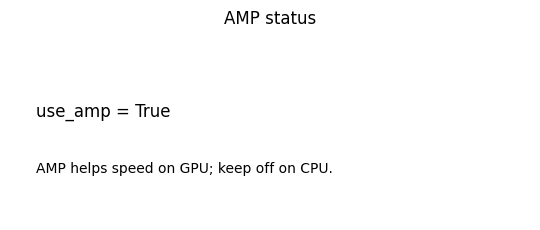

In [223]:
# AMP setup + visual “if GPU = on/ if Cpu = off
use_amp = (DEVICE.type == "cuda")
scaler = torch.amp.GradScaler("cuda") if use_amp else None

print("AMP enabled:", use_amp)

plt.figure(figsize=(5.5, 2.4))
plt.title("AMP status")
plt.text(0.05, 0.55, f"use_amp = {use_amp}", fontsize=12)
plt.text(0.05, 0.25, "AMP helps speed on GPU; keep off on CPU.", fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.show()

loss_fn = nn.CrossEntropyLoss()

In [224]:
#Train one epoch function
def train_one_epoch(model, loader):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    opt_steps = 0

    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        x = batch["input_ids"].to(DEVICE)
        m = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        if use_amp:
            with torch.amp.autocast(device_type="cuda"):
                logits = model(x, m)
                loss = loss_fn(logits, y) / GRAD_ACCUM
            scaler.scale(loss).backward()
        else:
            logits = model(x, m)
            loss = loss_fn(logits, y) / GRAD_ACCUM
            loss.backward()

        total_loss += float(loss.item()) * GRAD_ACCUM

        if (step % GRAD_ACCUM == 0) or (step == len(loader)):
            if use_amp:
                scaler.unscale_(optimizer)

            nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)

            if use_amp:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            opt_steps += 1

    return total_loss / len(loader), opt_steps

In [225]:
#Evaluate function
@torch.no_grad()
def evaluate(model, loader, desc="eval"):
    model.eval()

    total_loss = 0.0
    all_logits = []
    all_labels = []

    for batch in tqdm(loader, desc=desc, leave=False):
        x = batch["input_ids"].to(DEVICE)
        m = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        logits = model(x, m)
        loss = loss_fn(logits, y)

        total_loss += float(loss.item())
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)

    return {
        "loss": total_loss / len(loader),
        "acc": accuracy_from_logits(logits, labels),
        "macro_f1": macro_f1_from_logits(logits, labels, NUM_CLASSES),
        "logits": logits,
        "labels": labels
    }


Epoch 1/3


train:   0%|          | 0/584 [00:00<?, ?it/s]

eval-train:   0%|          | 0/584 [00:00<?, ?it/s]

eval-val:   0%|          | 0/103 [00:00<?, ?it/s]

Train: loss=0.7859 acc=0.7596 macroF1=0.7385
Val: loss=0.9609 acc=0.7112 macroF1=0.6891


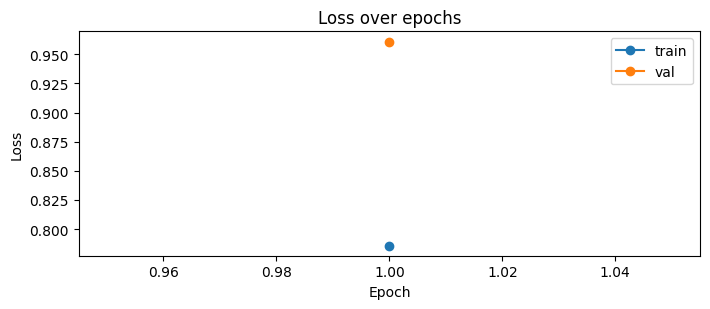

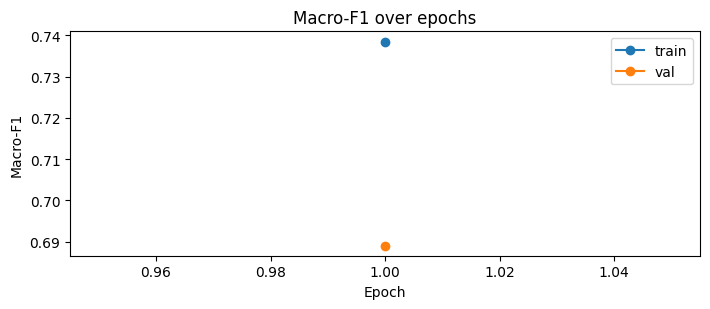

Saved new best model.

Epoch 2/3


train:   0%|          | 0/584 [00:00<?, ?it/s]

eval-train:   0%|          | 0/584 [00:00<?, ?it/s]

eval-val:   0%|          | 0/103 [00:00<?, ?it/s]

Train: loss=0.5464 acc=0.8319 macroF1=0.8131
Val: loss=0.8684 acc=0.7445 macroF1=0.7255


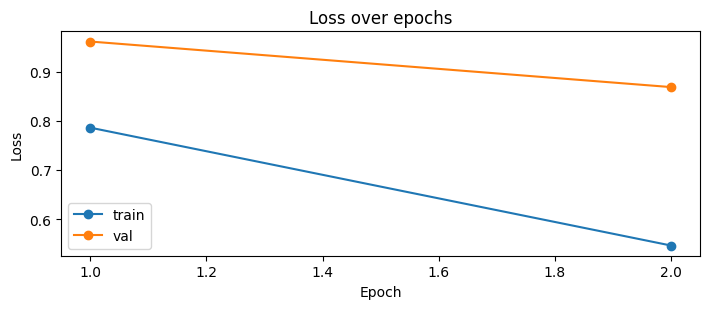

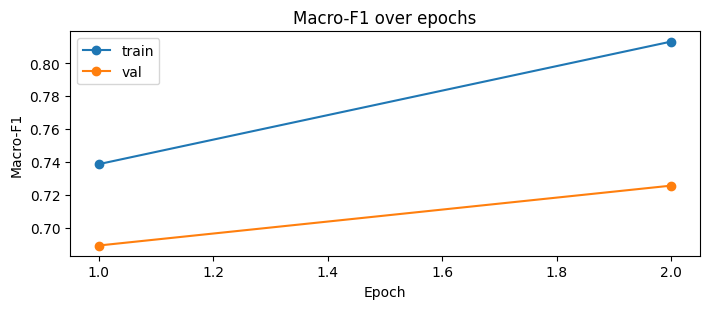

Saved new best model.

Epoch 3/3


train:   0%|          | 0/584 [00:00<?, ?it/s]

eval-train:   0%|          | 0/584 [00:00<?, ?it/s]

eval-val:   0%|          | 0/103 [00:00<?, ?it/s]

Train: loss=0.4498 acc=0.8636 macroF1=0.8489
Val: loss=0.8521 acc=0.7439 macroF1=0.7258


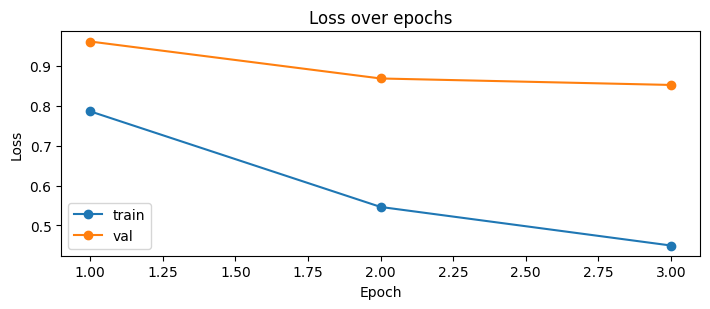

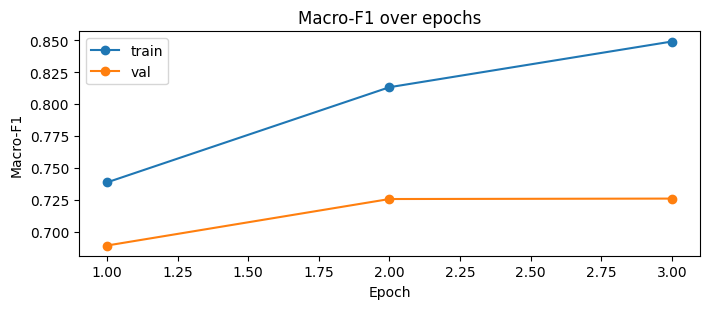

Saved new best model.


In [226]:
#Training loop + live history plots (loss & macro-F1)
best_f1 = -1.0
best_state = None
history = []

patience = 2
bad_epochs = 0
min_delta = 1e-4

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss_stream, opt_steps = train_one_epoch(model, train_loader)

    train_metrics = evaluate(model, train_eval_loader, desc="eval-train")
    val_metrics = evaluate(model, val_loader, desc="eval-val")

    print("Train:",
          f"loss={train_metrics['loss']:.4f}",
          f"acc={train_metrics['acc']:.4f}",
          f"macroF1={train_metrics['macro_f1']:.4f}")

    print("Val:",
          f"loss={val_metrics['loss']:.4f}",
          f"acc={val_metrics['acc']:.4f}",
          f"macroF1={val_metrics['macro_f1']:.4f}")

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_macro_f1": val_metrics["macro_f1"]
    })

    # visual: update learning curves each epoch
    hist_df = pd.DataFrame(history)

    plt.figure(figsize=(7.2, 3.2))
    plt.title("Loss over epochs")
    plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7.2, 3.2))
    plt.title("Macro-F1 over epochs")
    plt.plot(hist_df["epoch"], hist_df["train_macro_f1"], marker="o", label="train")
    plt.plot(hist_df["epoch"], hist_df["val_macro_f1"], marker="o", label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if val_metrics["macro_f1"] > best_f1 + min_delta:
        best_f1 = val_metrics["macro_f1"]
        best_state = {k: v.detach().cpu().clone()
                      for k, v in model.state_dict().items()}
        bad_epochs = 0
        print("Saved new best model.")
    else:
        bad_epochs += 1
        print(f"No improvement ({bad_epochs}/{patience})")

    if bad_epochs >= patience:
        print("Early stopping.")
        break

eval-test:   0%|          | 0/458 [00:00<?, ?it/s]

Final test results:
loss: 0.9618
accuracy: 0.7166
macroF1: 0.6970


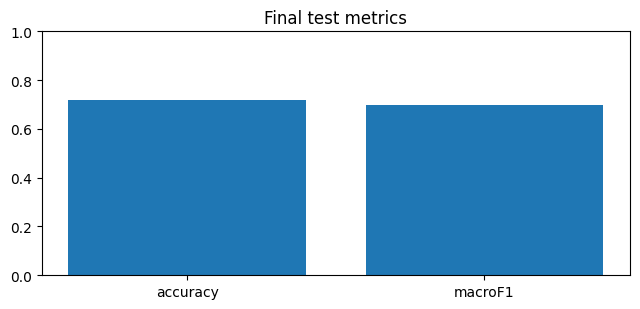

In [227]:
# Load best model + test eval
model.load_state_dict(best_state)
model.to(DEVICE)

test_metrics = evaluate(model, test_loader, desc="eval-test")

print("Final test results:")
print("loss:", f"{test_metrics['loss']:.4f}")
print("accuracy:", f"{test_metrics['acc']:.4f}")
print("macroF1:", f"{test_metrics['macro_f1']:.4f}")

test_loss = test_metrics["loss"]
test_acc = test_metrics["acc"]
test_macro_f1 = test_metrics["macro_f1"]

# visual: final metrics bars
plt.figure(figsize=(6.5, 3.2))
plt.title("Final test metrics")
plt.bar(["accuracy", "macroF1"], [test_acc, test_macro_f1])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Per-class performance (worst first):
19 talk.religion.misc        prec=0.284 rec=0.118 f1=0.167 n=245
 0 alt.atheism               prec=0.469 rec=0.457 f1=0.463 n=311
18 talk.politics.misc        prec=0.510 rec=0.482 f1=0.496 n=303
16 talk.politics.guns        prec=0.557 rec=0.689 f1=0.616 n=354
 3 comp.sys.ibm.pc.hardware  prec=0.589 rec=0.663 f1=0.624 n=386
12 sci.electronics           prec=0.660 rec=0.619 f1=0.639 n=383
 2 comp.os.ms-windows.misc   prec=0.662 rec=0.652 f1=0.657 n=379
 4 comp.sys.mac.hardware     prec=0.711 rec=0.704 f1=0.707 n=371
 1 comp.graphics             prec=0.697 rec=0.719 f1=0.708 n=384
 8 rec.motorcycles           prec=0.751 rec=0.694 f1=0.721 n=386
15 soc.religion.christian    prec=0.650 rec=0.852 f1=0.737 n=384
11 sci.crypt                 prec=0.730 rec=0.755 f1=0.743 n=380
 7 rec.autos                 prec=0.791 rec=0.797 f1=0.794 n=375
 6 misc.forsale              prec=0.797 rec=0.801 f1=0.799 n=382
14 sci.space                 prec=0.808 rec=0.802 f1=

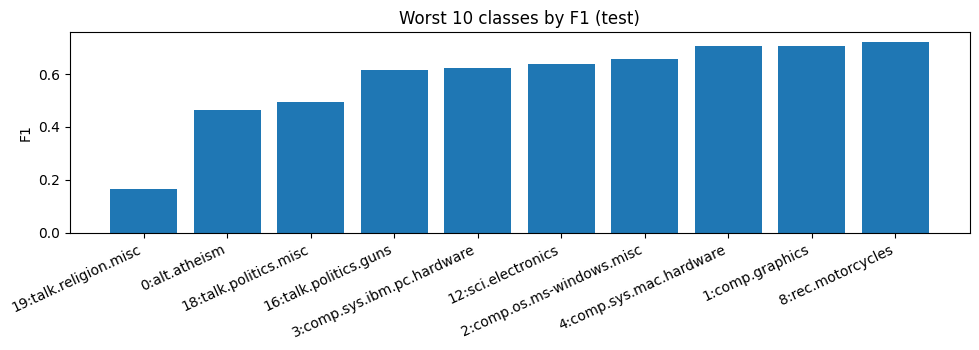

Section 6 finished.


In [228]:
#Per-class performance (worst first)
rows = per_class_scores(test_metrics["logits"], test_metrics["labels"], NUM_CLASSES)

print("Per-class performance (worst first):")
for cid, p, r, f1, supp in rows:
    print(f"{cid:2d} {id2label[cid]:25s} "
          f"prec={p:.3f} rec={r:.3f} f1={f1:.3f} n={supp}")

# visual: worst 10 classes by F1
worst10 = rows[:10]
names = [f"{cid}:{id2label[cid]}" for cid, *_ in worst10]
f1s = [f1 for _, _, _, f1, _ in worst10]

plt.figure(figsize=(10, 3.6))
plt.title("Worst 10 classes by F1 (test)")
plt.bar(names, f1s)
plt.ylabel("F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("Section 6 finished.")

# Test eval + Confusion Matrix + Error Analysis

Device: cuda
Classes: 20
MAX_LEN: 256
Test batches: 458


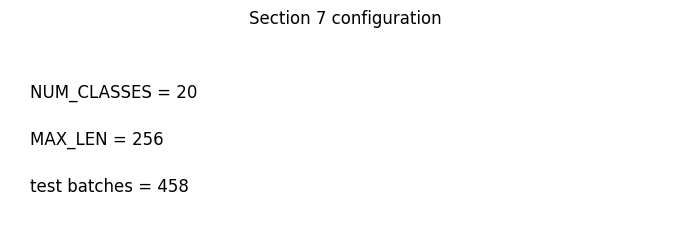

In [229]:
#Checks + config summary
need = ["model", "test_loader", "DEVICE", "id2label", "tokenizer", "MAX_LEN"]
for k in need:
    if k not in globals():
        raise RuntimeError(f"Missing {k}. Run earlier sections.")

if "best_state_dict" in globals():
    BEST = best_state_dict
elif "best_state" in globals():
    BEST = best_state
else:
    raise RuntimeError("Missing best checkpoint (best_state_dict or best_state). Run Section 6.")

NUM_CLASSES = len(id2label) if "NUM_CLASSES" not in globals() else NUM_CLASSES
label_names = [id2label[i] for i in range(NUM_CLASSES)]

print("Device:", DEVICE)
print("Classes:", NUM_CLASSES)
print("MAX_LEN:", MAX_LEN)
print("Test batches:", len(test_loader))

plt.figure(figsize=(7, 2.4))
plt.title("Section 7 configuration")
plt.text(0.03, 0.65, f"NUM_CLASSES = {NUM_CLASSES}", fontsize=12)
plt.text(0.03, 0.40, f"MAX_LEN = {MAX_LEN}", fontsize=12)
plt.text(0.03, 0.15, f"test batches = {len(test_loader)}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

Loaded best checkpoint -> model.eval()


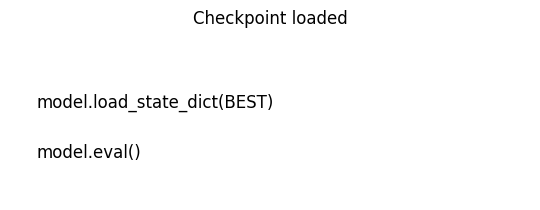

In [230]:
#load best moel
model.load_state_dict(BEST)
model.to(DEVICE)
model.eval()

print("Loaded best checkpoint -> model.eval()")

plt.figure(figsize=(5.5, 2.2))
plt.title("Checkpoint loaded")
plt.text(0.05, 0.55, "model.load_state_dict(BEST)", fontsize=12)
plt.text(0.05, 0.25, "model.eval()", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

In [231]:
#Helper functions (CM + PRF + plotting)
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return float((preds == labels).float().mean().item())

def confusion_counts(preds, labels, C):
    cm = np.zeros((C, C), dtype=np.int64)
    for t, p in zip(labels, preds):
        cm[int(t), int(p)] += 1
    return cm

def prf_from_cm(cm):
    C = cm.shape[0]
    support = cm.sum(axis=1)
    colsum = cm.sum(axis=0)

    prec = np.zeros(C, dtype=np.float64)
    rec  = np.zeros(C, dtype=np.float64)
    f1   = np.zeros(C, dtype=np.float64)

    for c in range(C):
        tp = cm[c, c]
        fp = colsum[c] - tp
        fn = support[c] - tp

        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        f = (2 * p * r / (p + r)) if (p + r) else 0.0

        prec[c], rec[c], f1[c] = p, r, f

    return prec, rec, f1, support

def pad_right_2d(x, width, pad_value):
    B, L = x.shape
    if L == width:
        return x
    if L > width:
        return x[:, :width]
    pad = torch.full((B, width - L), pad_value, dtype=x.dtype, device=x.device)
    return torch.cat([x, pad], dim=1)

def plot_cm(mat, title, names, cbar_label):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(mat, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    C = len(names)
    ax.set_xticks(np.arange(C))
    ax.set_yticks(np.arange(C))
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_yticklabels(names, fontsize=7)

    cb = plt.colorbar(im, ax=ax)
    cb.set_label(cbar_label)

    plt.tight_layout()
    plt.show()




Collected:
  logits: (7317, 20)
  labels: (7317,)
  ids   : (7317, 256)
  mask  : (7317, 256)


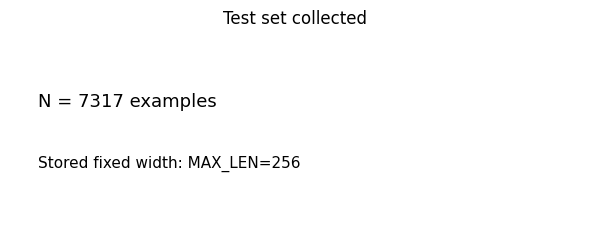

In [232]:
#Run test loop (collect logits/labels/inputs) + progress 
loss_fn = nn.CrossEntropyLoss()
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

all_logits = []
all_labels = []
all_ids = []
all_mask = []

total_loss = 0.0
steps = 0

with torch.no_grad():
    for batch in test_loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        logits = model(ids, mask)
        loss = loss_fn(logits, y)

        total_loss += float(loss.item())
        steps += 1

        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())

        all_ids.append(pad_right_2d(ids, MAX_LEN, PAD_ID).cpu())
        all_mask.append(pad_right_2d(mask, MAX_LEN, 0).cpu())

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_ids = torch.cat(all_ids, dim=0)
all_mask = torch.cat(all_mask, dim=0)

print("Collected:")
print("  logits:", tuple(all_logits.shape))
print("  labels:", tuple(all_labels.shape))
print("  ids   :", tuple(all_ids.shape))
print("  mask  :", tuple(all_mask.shape))

# visual: show sample count
plt.figure(figsize=(6, 2.4))
plt.title("Test set collected")
plt.text(0.05, 0.60, f"N = {all_labels.shape[0]} examples", fontsize=13)
plt.text(0.05, 0.28, f"Stored fixed width: MAX_LEN={MAX_LEN}", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()

Final TEST:
  loss   : 0.9618
  acc    : 0.7166
  macroF1: 0.6970


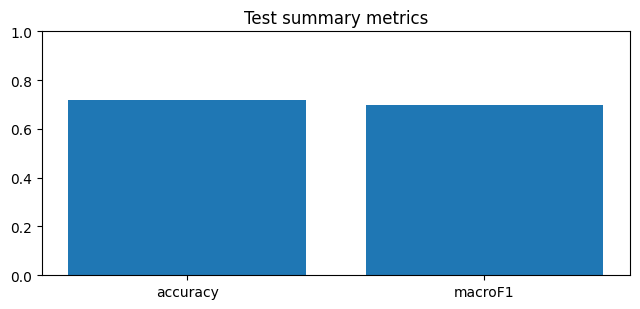

In [233]:
#Compute metrics + compact visuals
test_loss = total_loss / max(steps, 1)
test_acc = accuracy_from_logits(all_logits, all_labels)

preds = all_logits.argmax(dim=1).numpy()
labels_np = all_labels.numpy()

cm = confusion_counts(preds, labels_np, NUM_CLASSES)
prec, rec, f1, support = prf_from_cm(cm)
test_macro_f1 = float(f1.mean())

print("Final TEST:")
print("  loss   :", f"{test_loss:.4f}")
print("  acc    :", f"{test_acc:.4f}")
print("  macroF1:", f"{test_macro_f1:.4f}")

# visual: summary bars
plt.figure(figsize=(6.5, 3.2))
plt.title("Test summary metrics")
plt.bar(["accuracy", "macroF1"], [test_acc, test_macro_f1])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

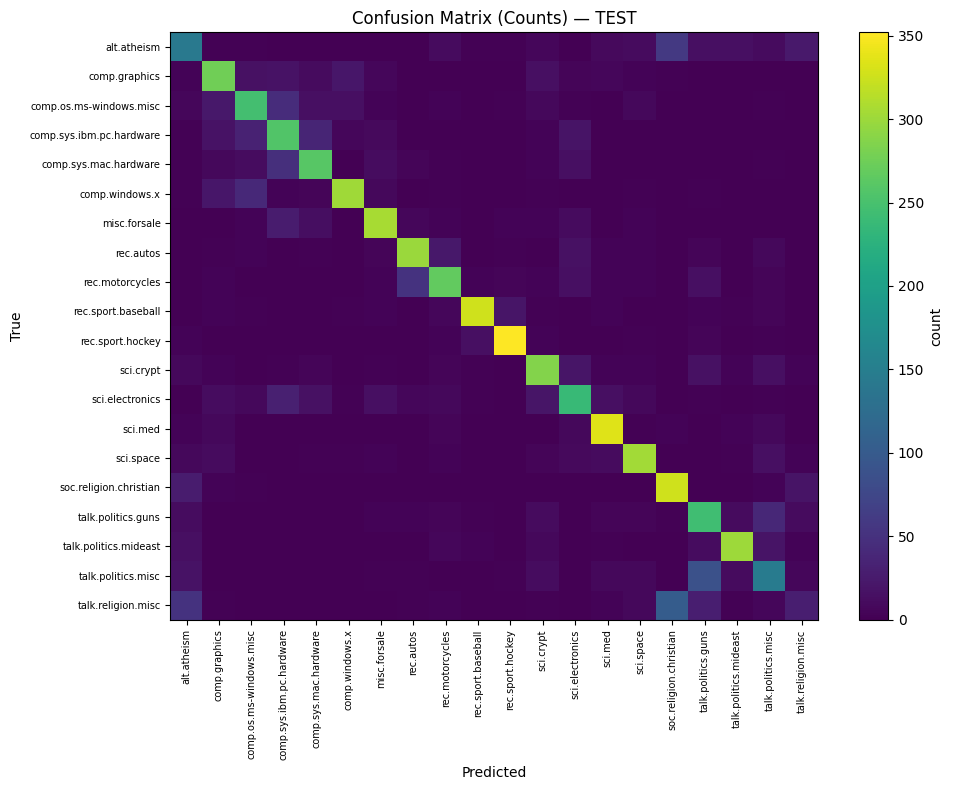

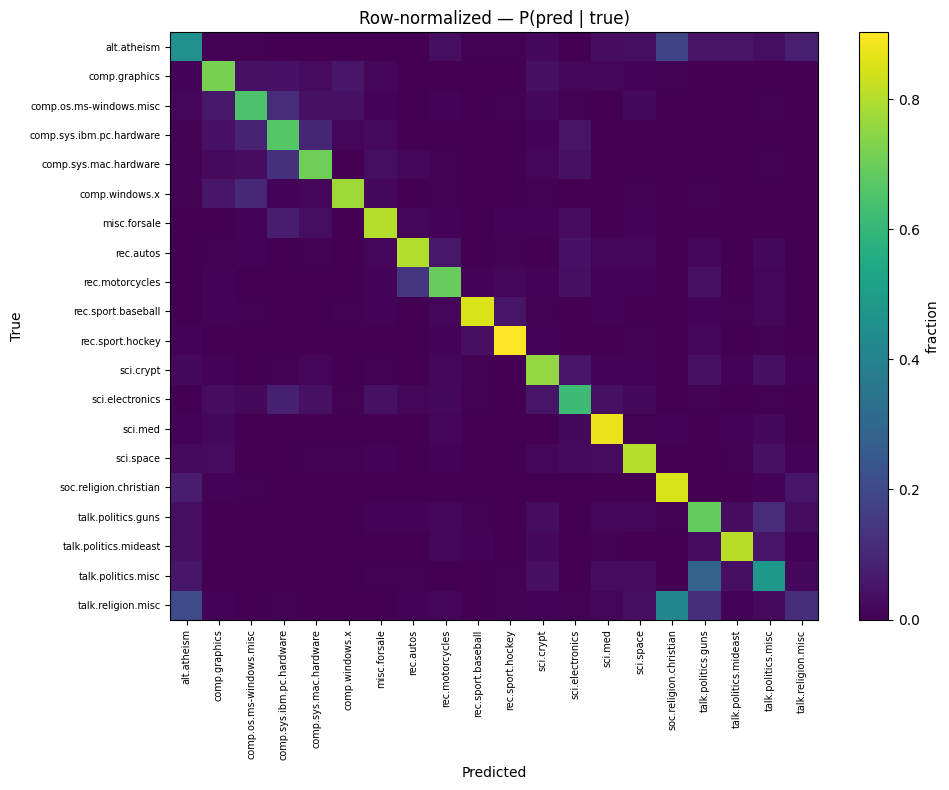

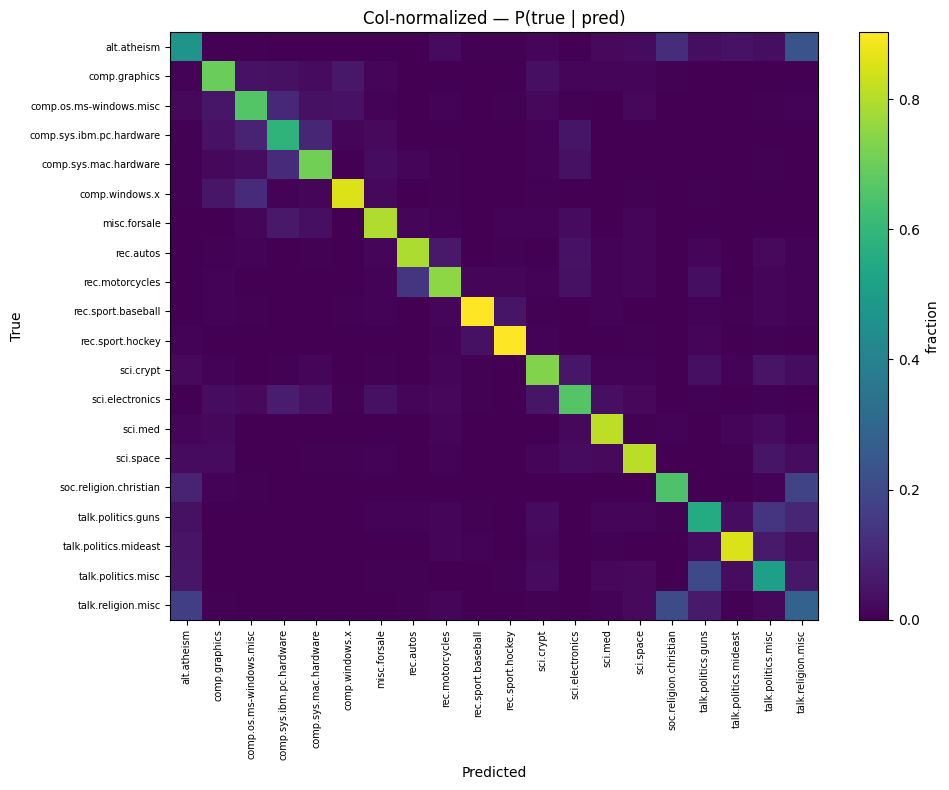

In [234]:
#Confusion matrices (counts + normalized)
row_sum = cm.sum(axis=1, keepdims=True)
col_sum = cm.sum(axis=0, keepdims=True)

cm_row = cm / np.maximum(row_sum, 1)
cm_col = cm / np.maximum(col_sum, 1)

plot_cm(cm, "Confusion Matrix (Counts) — TEST", label_names, "count")
plot_cm(cm_row, "Row-normalized — P(pred | true)", label_names, "fraction")
plot_cm(cm_col, "Col-normalized — P(true | pred)", label_names, "fraction")

id  label                           prec     rec      f1      n
----------------------------------------------------------------------
19  talk.religion.misc             0.284   0.118   0.167    245
 0  alt.atheism                    0.469   0.457   0.463    311
18  talk.politics.misc             0.510   0.482   0.496    303
16  talk.politics.guns             0.557   0.689   0.616    354
 3  comp.sys.ibm.pc.hardware       0.589   0.663   0.624    386
12  sci.electronics                0.660   0.619   0.639    383
 2  comp.os.ms-windows.misc        0.662   0.652   0.657    379
 4  comp.sys.mac.hardware          0.711   0.704   0.707    371
 1  comp.graphics                  0.697   0.719   0.708    384
 8  rec.motorcycles                0.751   0.694   0.721    386
15  soc.religion.christian         0.650   0.852   0.737    384
11  sci.crypt                      0.730   0.755   0.743    380
 7  rec.autos                      0.791   0.797   0.794    375
 6  misc.forsale                 

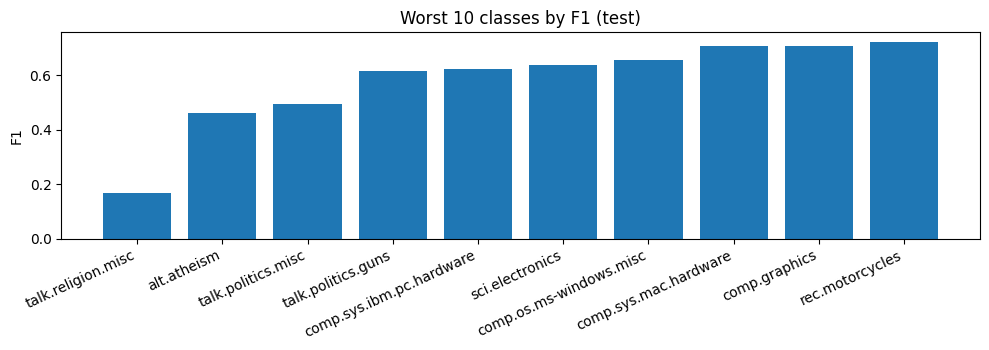

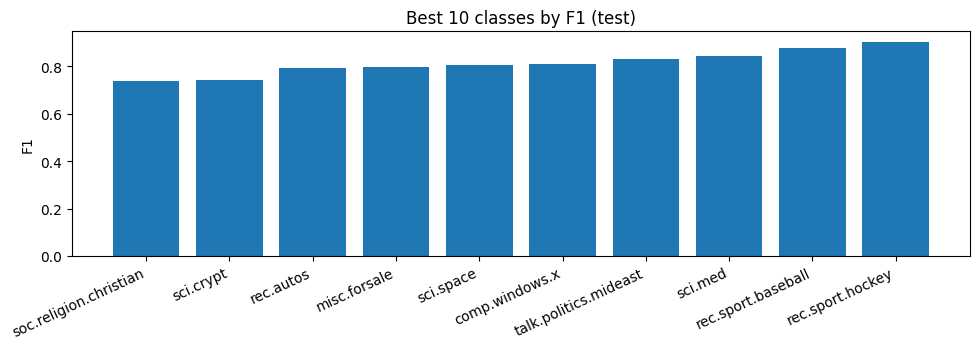

In [235]:
#Per-class table (worst→best)
order = np.argsort(f1)

print(f"{'id':>2}  {'label':<28}  {'prec':>6}  {'rec':>6}  {'f1':>6}  {'n':>5}")
print("-" * 70)
for c in order:
    print(f"{c:>2}  {label_names[c]:<28}  {prec[c]:>6.3f}  {rec[c]:>6.3f}  {f1[c]:>6.3f}  {support[c]:>5d}")

# visual: worst 10 and best 10 F1 (clean for report)
worst10 = order[:10]
best10  = order[-10:]

plt.figure(figsize=(10, 3.6))
plt.title("Worst 10 classes by F1 (test)")
plt.bar([label_names[i] for i in worst10], [f1[i] for i in worst10])
plt.ylabel("F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.6))
plt.title("Best 10 classes by F1 (test)")
plt.bar([label_names[i] for i in best10], [f1[i] for i in best10])
plt.ylabel("F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Top confusion pairs:
- true=talk.religion.misc        -> pred=soc.religion.christian    | count=103
- true=talk.politics.misc        -> pred=talk.politics.guns        | count=87
- true=alt.atheism               -> pred=soc.religion.christian    | count=59
- true=rec.motorcycles           -> pred=rec.autos                 | count=52
- true=talk.religion.misc        -> pred=alt.atheism               | count=51
- true=comp.sys.mac.hardware     -> pred=comp.sys.ibm.pc.hardware  | count=48
- true=comp.os.ms-windows.misc   -> pred=comp.sys.ibm.pc.hardware  | count=44
- true=comp.windows.x            -> pred=comp.os.ms-windows.misc   | count=40
- true=talk.politics.guns        -> pred=talk.politics.misc        | count=39
- true=comp.sys.ibm.pc.hardware  -> pred=comp.sys.mac.hardware     | count=36
- true=comp.sys.ibm.pc.hardware  -> pred=comp.os.ms-windows.misc   | count=34
- true=sci.electronics           -> pred=comp.sys.ibm.pc.hardware  | count=31
- true=talk.religion.misc        -> pred=t

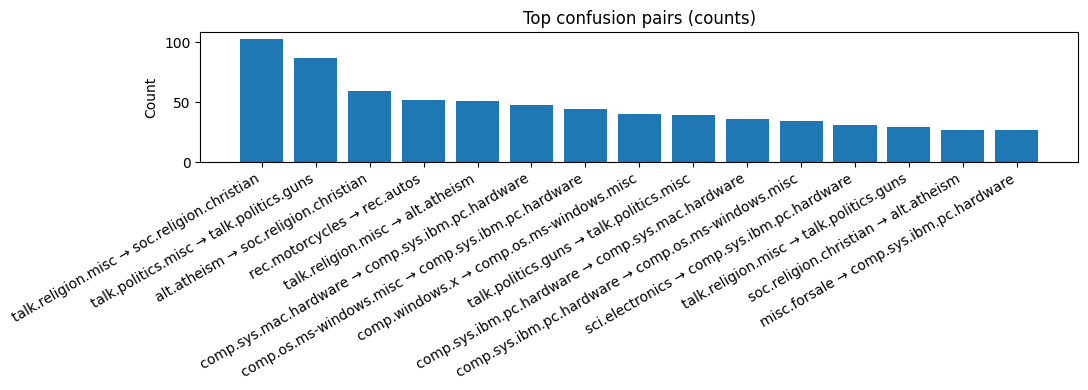

In [236]:
#Top confusion pairs
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

flat = np.argsort(cm_off.ravel())[::-1]
topk = 15

pairs = []
counts = []

print("Top confusion pairs:")
shown = 0
for idx in flat:
    cnt = int(cm_off.ravel()[idx])
    if cnt == 0:
        break
    t = idx // NUM_CLASSES
    p = idx % NUM_CLASSES
    pairs.append(f"{label_names[t]} → {label_names[p]}")
    counts.append(cnt)
    print(f"- true={label_names[t]:25s} -> pred={label_names[p]:25s} | count={cnt}")
    shown += 1
    if shown >= topk:
        break

# visual: top confusion counts
plt.figure(figsize=(11, 4))
plt.title("Top confusion pairs (counts)")
plt.bar(pairs, counts)
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Wrong predictions: 2074 / 7317


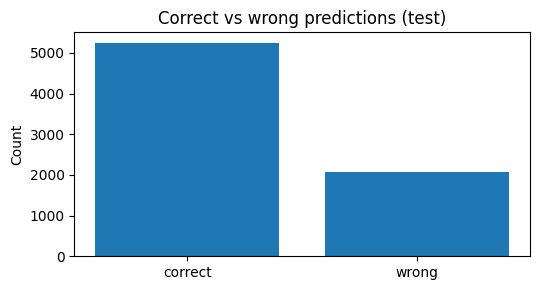

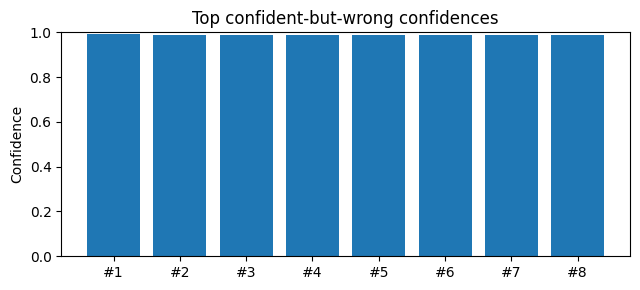


Top 8 confident-but-wrong examples:

------------------------------------------------------------
#1  conf=0.991
TRUE:  9 rec.sport.baseball
PRED: 10 rec.sport.hockey
text: since roger is a canadian who probably knows nothing about baseball i am gonna try to explain it to him in terms of hockey... according to his logic... i can say that since 1988... bob errey is better than wayne gretzky hey... errey contributed to 2 cups while good old wayne has won nothing... ( i think the kings shoul ...

------------------------------------------------------------
#2  conf=0.990
TRUE: 10 rec.sport.hockey
PRED:  9 rec.sport.baseball
text: unfortunately, roger is now over at r. s. baseball spewing his expertise ( i. e. being a dickhead ). i guess he is afraid of posting anything here, because he knows what to expect. ...

------------------------------------------------------------
#3  conf=0.990
TRUE: 12 sci.electronics
PRED: 13 sci.med
text: not only is benzene a carcinogen, it is adsorbed throu

In [237]:
#Precision & Recall plots
probs = F.softmax(all_logits, dim=1)
preds_t = all_logits.argmax(dim=1)

wrong = (preds_t != all_labels)
wrong_idx = torch.where(wrong)[0]

num_wrong = int(wrong.sum().item())
N = int(all_labels.shape[0])

print("Wrong predictions:", num_wrong, "/", N)

# visual: correct vs wrong
plt.figure(figsize=(5.5, 3))
plt.title("Correct vs wrong predictions (test)")
plt.bar(["correct", "wrong"], [N - num_wrong, num_wrong])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

TOP_N = 8
if len(wrong_idx) == 0:
    print("No mistakes found (rare).")
else:
    wrong_conf = probs[wrong_idx, preds_t[wrong_idx]]
    pick = wrong_idx[torch.argsort(wrong_conf, descending=True)[:TOP_N]]

    # visual: confidences of selected wrong examples
    confs = [float(probs[i, int(preds_t[i].item())].item()) for i in pick.tolist()]
    plt.figure(figsize=(6.5, 3))
    plt.title("Top confident-but-wrong confidences")
    plt.bar([f"#{i+1}" for i in range(len(confs))], confs)
    plt.ylim(0, 1)
    plt.ylabel("Confidence")
    plt.tight_layout()
    plt.show()

    print(f"\nTop {min(TOP_N, len(pick))} confident-but-wrong examples:")
    for rank, i in enumerate(pick.tolist(), start=1):
        t = int(all_labels[i].item())
        p = int(preds_t[i].item())
        conf = float(probs[i, p].item())

        ids = all_ids[i].tolist()
        m = all_mask[i].tolist()
        ids_nopad = [tok for tok, mm in zip(ids, m) if mm == 1]

        txt = tokenizer.decode(ids_nopad, skip_special_tokens=True).replace("\n", " ")
        print("\n" + "-" * 60)
        print(f"#{rank}  conf={conf:.3f}")
        print("TRUE:", f"{t:2d}", label_names[t])
        print("PRED:", f"{p:2d}", label_names[p])
        print("text:", txt[:320], "...")

# Domain shift test (modern_test_sample.csv)

Section 8 ready.
classes: 20 | max_len: 256 | strategy: head_tail | device: cuda


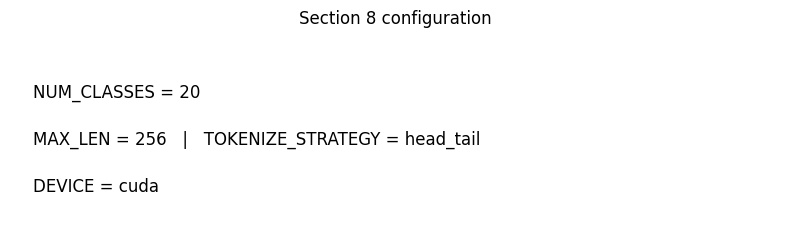

In [238]:
#Checks + config its oky or not
need = ["model", "DEVICE", "tokenizer", "clean_text_basic", "MAX_LEN", "TOKENIZE_STRATEGY", "id2label"]
for k in need:
    if k not in globals():
        raise RuntimeError(f"Missing {k}. Run earlier sections first.")

if "best_state_dict" in globals():
    BEST = best_state_dict
elif "best_state" in globals():
    BEST = best_state
else:
    raise RuntimeError("Missing best checkpoint (best_state_dict or best_state). Run Section 6.")

NUM_CLASSES = len(id2label)
label_names = [id2label[i] for i in range(NUM_CLASSES)]

if "label2id" not in globals():
    label2id = {v: k for k, v in id2label.items()}

print("Section 8 ready.")
print("classes:", NUM_CLASSES, "| max_len:", MAX_LEN, "| strategy:", TOKENIZE_STRATEGY, "| device:", DEVICE)

plt.figure(figsize=(8, 2.4))
plt.title("Section 8 configuration")
plt.text(0.03, 0.65, f"NUM_CLASSES = {NUM_CLASSES}", fontsize=12)
plt.text(0.03, 0.40, f"MAX_LEN = {MAX_LEN}   |   TOKENIZE_STRATEGY = {TOKENIZE_STRATEGY}", fontsize=12)
plt.text(0.03, 0.15, f"DEVICE = {DEVICE}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

Loaded modern CSV: /kaggle/input/datasets/babaruzair/modern-test-sample/modern_test_sample (1).csv
Rows: 100
Columns: ['id', 'text', 'label', 'label_name', 'source']


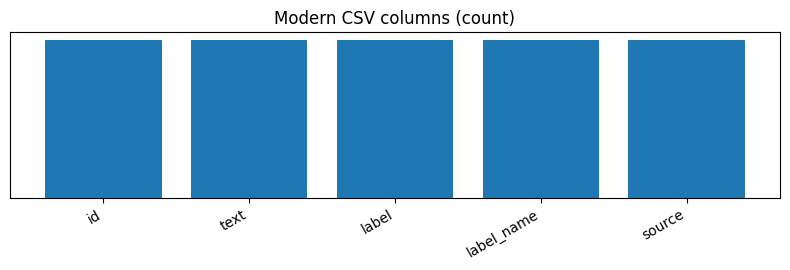

In [239]:
#Load modern CSV
MODERN_PATH = "/kaggle/input/datasets/babaruzair/modern-test-sample/modern_test_sample (1).csv"
if not os.path.exists(MODERN_PATH):
    raise FileNotFoundError(MODERN_PATH)

df = pd.read_csv(MODERN_PATH, encoding="cp1252")

junk = [c for c in df.columns if c.lower().startswith("unnamed")]
if junk:
    df.drop(columns=junk, inplace=True)

if "text" not in df.columns:
    raise ValueError("modern csv must have a `text` column")

print("Loaded modern CSV:", MODERN_PATH)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# visual: show which columns are present (simple)
cols = df.columns.tolist()
plt.figure(figsize=(8, 2.8))
plt.title("Modern CSV columns (count)")
plt.bar(cols, [1]*len(cols))
plt.yticks([])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Label column mapped -> label_id ready.
Unique labels in modern data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


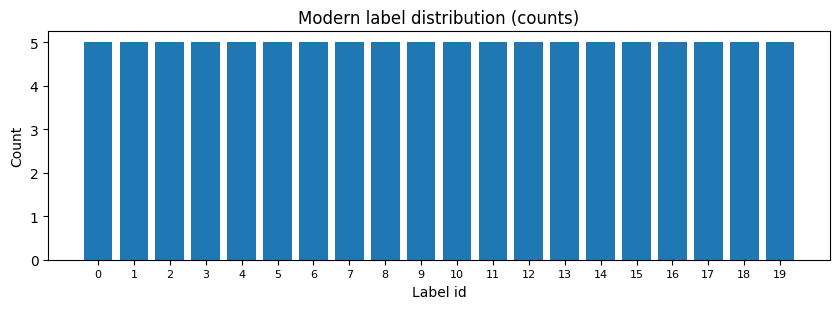

In [240]:
#Build/validate label_id +  label distribution

# labels: support label_name OR label_id OR label
if "label_name" in df.columns:
    df["label_name"] = df["label_name"].astype(str).str.strip()
    df["label_id"] = df["label_name"].map(label2id)

    bad = df[df["label_id"].isna()]["label_name"].unique().tolist()
    if bad:
        raise ValueError(
            f"Unmapped label_name values: {bad}\n\n"
            f"Expected one of:\n{label_names}"
        )
    df["label_id"] = df["label_id"].astype(int)

elif "label_id" in df.columns:
    df["label_id"] = df["label_id"].astype(int)

elif "label" in df.columns:
    df["label_id"] = df["label"].astype(int)

else:
    raise ValueError("modern csv must have label_name or label_id or label")

print("Label column mapped -> label_id ready.")
print("Unique labels in modern data:", sorted(df["label_id"].unique().tolist()))

# visual: label distribution (counts)
counts = df["label_id"].value_counts().sort_index()
plt.figure(figsize=(8.5, 3.2))
plt.title("Modern label distribution (counts)")
plt.bar(counts.index, counts.values)
plt.xlabel("Label id")
plt.ylabel("Count")
plt.xticks(counts.index, fontsize=8)
plt.tight_layout()
plt.show()

Cleaned text.
Rows: 100 -> 100 | removed empty: 0


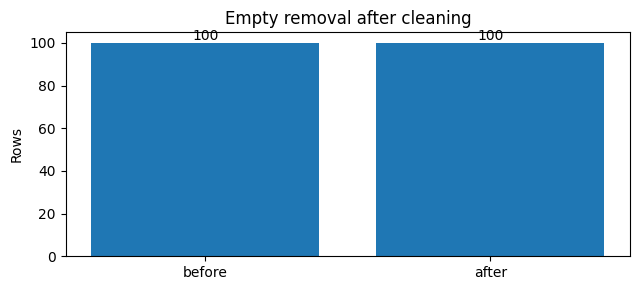

In [241]:
#Clean text + remove empties
before = len(df)
df["text_clean"] = df["text"].apply(clean_text_basic)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
after = len(df)

print("Cleaned text.")
print("Rows:", before, "->", after, "| removed empty:", before - after)

plt.figure(figsize=(6.5, 3))
plt.title("Empty removal after cleaning")
plt.bar(["before", "after"], [before, after])
plt.ylabel("Rows")
for i, v in enumerate([before, after]):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

dedup removed: 0
modern rows: 100


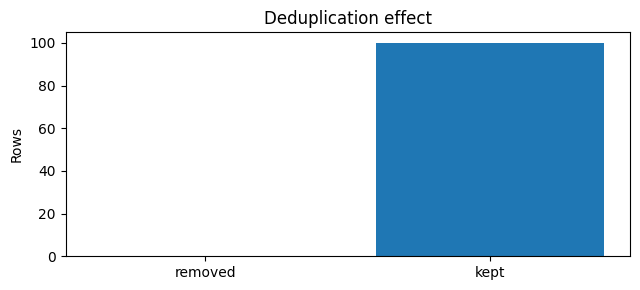

In [242]:
#check Deduplicate
REMOVE_DUPLICATES = True

if REMOVE_DUPLICATES:
    before = len(df)
    df.drop_duplicates(subset=["text_clean", "label_id"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    removed = before - len(df)
    print("dedup removed:", removed)
else:
    removed = 0
    print("dedup skipped")

print("modern rows:", len(df))

plt.figure(figsize=(6.5, 3))
plt.title("Deduplication effect")
plt.bar(["removed", "kept"], [removed, len(df)])
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

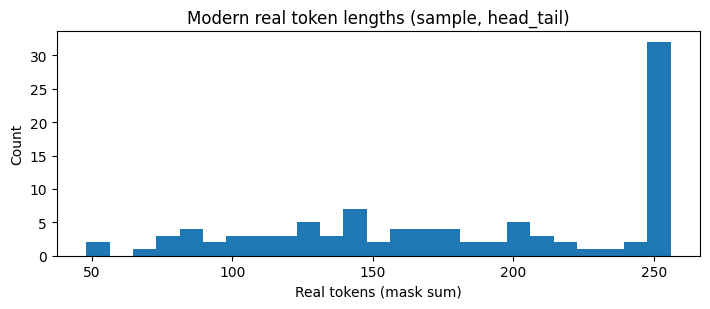

Length stats: min/mean/max = 48 182.7 256


In [243]:
#Tokenization helpers + quick length 
def enc_head_only(text):
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_tensors="pt"
    )
    return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

def enc_head_tail(text):
    ids = tokenizer.encode(text, add_special_tokens=False)

    budget = MAX_LEN - 2
    head = max(1, budget // 2)
    tail = budget - head

    if len(ids) > budget:
        ids = ids[:head] + ids[-tail:]

    ids = [tokenizer.cls_token_id] + ids + [tokenizer.sep_token_id]

    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    if len(ids) < MAX_LEN:
        ids = ids + [pad_id] * (MAX_LEN - len(ids))

    mask = [0 if t == pad_id else 1 for t in ids]
    return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.long)

# visual: real token lengths in modern set (sample)
sample_n = min(1000, len(df))
lens = []
for t in df["text_clean"].iloc[:sample_n]:
    if TOKENIZE_STRATEGY == "head_only":
        _, m = enc_head_only(t)
        lens.append(int(m.sum().item()))
    else:
        _, m = enc_head_tail(t)
        lens.append(int(m.sum().item()))

plt.figure(figsize=(7.2, 3.2))
plt.title(f"Modern real token lengths (sample, {TOKENIZE_STRATEGY})")
plt.hist(lens, bins=25)
plt.xlabel("Real tokens (mask sum)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Length stats: min/mean/max =", min(lens), round(sum(lens)/len(lens), 1), max(lens))

modern rows: 100
modern batches: 7


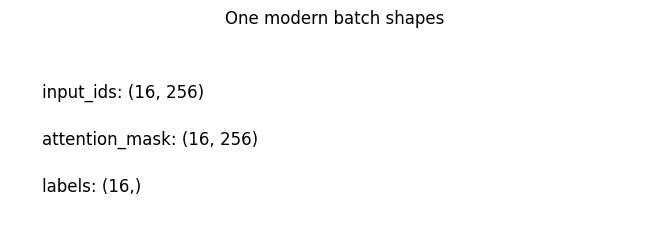

In [244]:
#Dataset + DataLoader + batch-shape
class ModernDS(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        text = row["text_clean"]
        y = int(row["label_id"])

        if TOKENIZE_STRATEGY == "head_only":
            ids, mask = enc_head_only(text)
        else:
            ids, mask = enc_head_tail(text)

        return {
            "input_ids": ids,
            "attention_mask": mask,
            "labels": torch.tensor(y, dtype=torch.long),
            "raw_text": row["text"],
            "text_clean": row["text_clean"],
        }

modern_ds = ModernDS(df)
modern_loader = DataLoader(modern_ds, batch_size=16, shuffle=False)

print("modern rows:", len(modern_ds))
print("modern batches:", len(modern_loader))

# visual: show one batch shape
b = next(iter(modern_loader))
plt.figure(figsize=(6.8, 2.4))
plt.title("One modern batch shapes")
plt.text(0.05, 0.65, f"input_ids: {tuple(b['input_ids'].shape)}", fontsize=12)
plt.text(0.05, 0.40, f"attention_mask: {tuple(b['attention_mask'].shape)}", fontsize=12)
plt.text(0.05, 0.15, f"labels: {tuple(b['labels'].shape)}", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

Modern results (so far):
loss    : 0.6290
accuracy: 0.8600


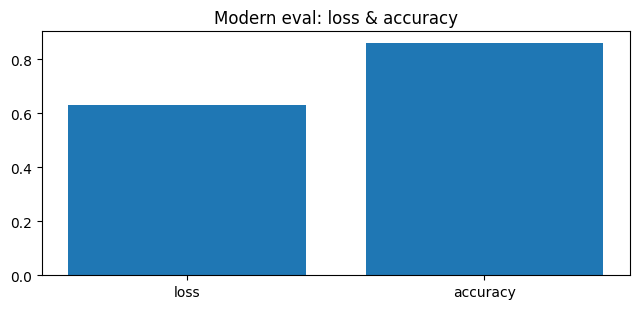

In [245]:
#Eval loop on modern data
model.load_state_dict(BEST)
model.to(DEVICE)
model.eval()

loss_fn = nn.CrossEntropyLoss()

all_logits = []
all_labels = []
all_clean = []
total_loss = 0.0

with torch.no_grad():
    for batch in modern_loader:
        x = batch["input_ids"].to(DEVICE)
        m = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        logits = model(x, m)
        loss = loss_fn(logits, y)

        total_loss += float(loss.item())
        all_logits.append(logits.cpu())
        all_labels.append(y.cpu())
        all_clean.extend(batch["text_clean"])

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)
preds = all_logits.argmax(dim=1)

modern_loss = total_loss / max(1, len(modern_loader))
modern_acc = float((preds == all_labels).float().mean().item())

print("Modern results (so far):")
print("loss    :", f"{modern_loss:.4f}")
print("accuracy:", f"{modern_acc:.4f}")

plt.figure(figsize=(6.5, 3.2))
plt.title("Modern eval: loss & accuracy")
plt.bar(["loss", "accuracy"], [modern_loss, modern_acc])
plt.tight_layout()
plt.show()

macro-F1: 0.8404


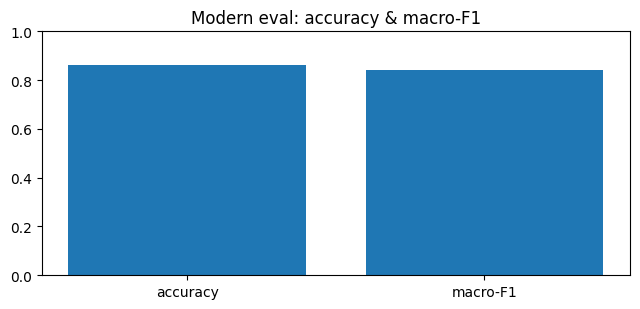

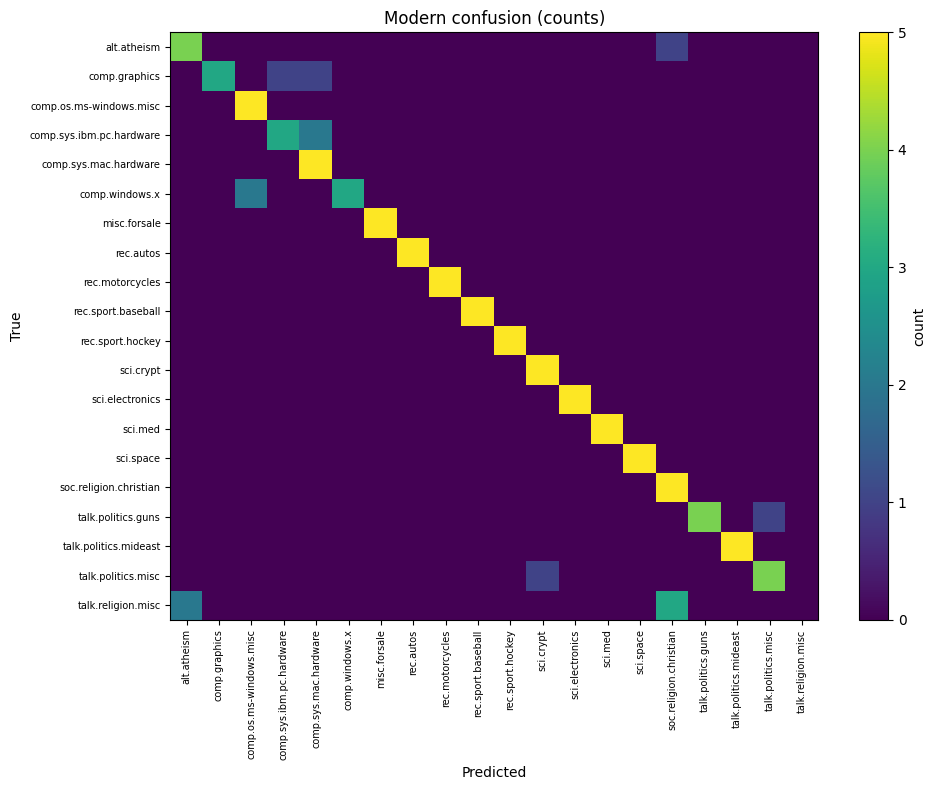

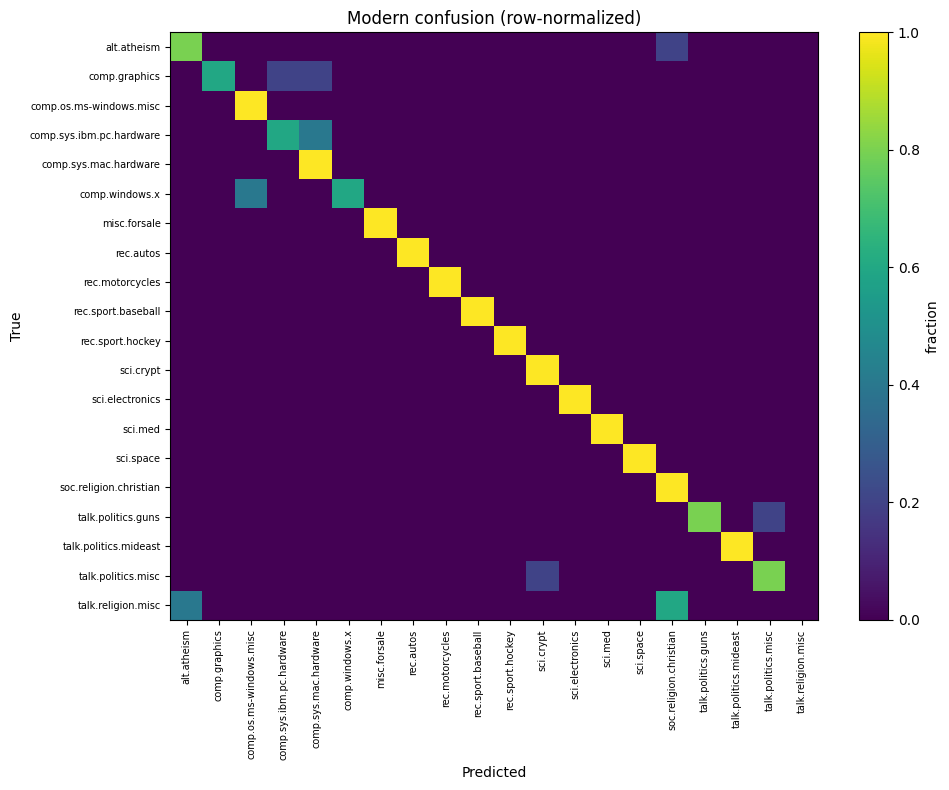

In [246]:
#Macro-F1 via confusion + confusion
pred_np = preds.numpy()
y_np = all_labels.numpy()

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
for t, p in zip(y_np, pred_np):
    cm[int(t), int(p)] += 1

support = cm.sum(axis=1)
colsum = cm.sum(axis=0)

prec = np.zeros(NUM_CLASSES, dtype=float)
rec  = np.zeros(NUM_CLASSES, dtype=float)
f1   = np.zeros(NUM_CLASSES, dtype=float)

for c in range(NUM_CLASSES):
    tp = cm[c, c]
    fp = colsum[c] - tp
    fn = support[c] - tp

    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = (2 * p * r / (p + r)) if (p + r) else 0.0

    prec[c], rec[c], f1[c] = p, r, f

modern_macro_f1 = float(f1.mean())

print("macro-F1:", f"{modern_macro_f1:.4f}")

# visual: summary bars
plt.figure(figsize=(6.5, 3.2))
plt.title("Modern eval: accuracy & macro-F1")
plt.bar(["accuracy", "macro-F1"], [modern_acc, modern_macro_f1])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# confusion matrices
row_sum = cm.sum(axis=1, keepdims=True)
cm_row = cm / np.maximum(row_sum, 1)

def plot_cm(mat, title, cbar):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(mat, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(NUM_CLASSES))
    ax.set_yticks(np.arange(NUM_CLASSES))
    ax.set_xticklabels(label_names, rotation=90, fontsize=7)
    ax.set_yticklabels(label_names, fontsize=7)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(cbar)
    plt.tight_layout()
    plt.show()

plot_cm(cm, "Modern confusion (counts)", "count")
plot_cm(cm_row, "Modern confusion (row-normalized)", "fraction")

Compare:
20NG test: 0.9618448955718607 0.7165504693984985 0.6970366900677273
Modern  : 0.6289746527160917 0.8600000143051147 0.8404384504384504
Gap (Modern - 20NG):
Δ acc    : +0.1434
Δ macroF1: +0.1434


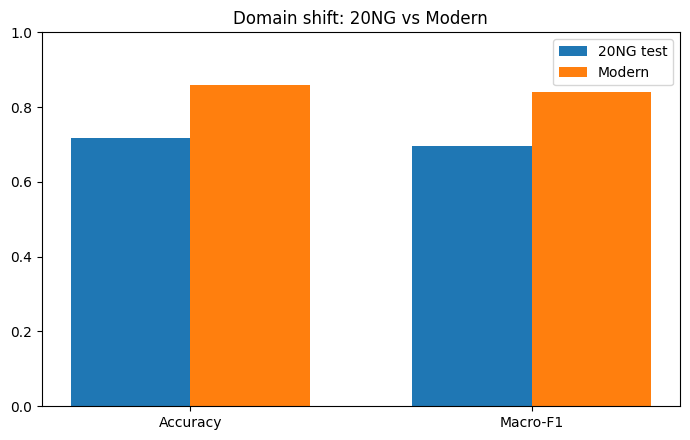

In [247]:
#Compare vs 20NG test + domain-shift 
test_loss_val = globals().get("test_loss", None)
test_acc_val  = globals().get("test_acc", None)
test_f1_val   = globals().get("test_macro_f1", None)

print("Compare:")
print("20NG test:", test_loss_val, test_acc_val, test_f1_val)
print("Modern  :", modern_loss, modern_acc, modern_macro_f1)

if test_acc_val is not None and test_f1_val is not None:
    print("Gap (Modern - 20NG):")
    print("Δ acc    :", f"{modern_acc - float(test_acc_val):+.4f}")
    print("Δ macroF1:", f"{modern_macro_f1 - float(test_f1_val):+.4f}")

vals_20 = [
    float(test_acc_val) if test_acc_val is not None else 0.0,
    float(test_f1_val) if test_f1_val is not None else 0.0
]
vals_m = [modern_acc, modern_macro_f1]

x = np.arange(2)
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, vals_20, w, label="20NG test")
ax.bar(x + w/2, vals_m,  w, label="Modern")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Macro-F1"])
ax.set_ylim(0, 1.0)
ax.set_title("Domain shift: 20NG vs Modern")
ax.legend()
plt.tight_layout()
plt.show()

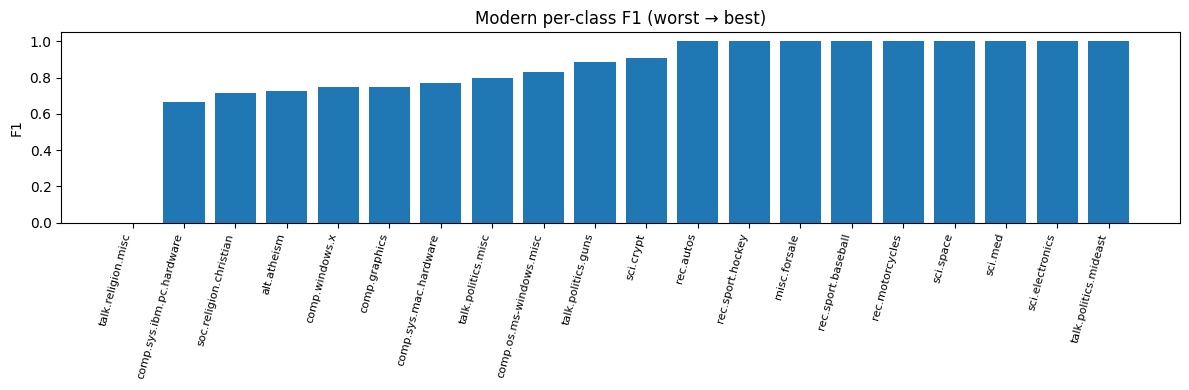

In [248]:
#Per-class F1 sorted
order = np.argsort(f1)

plt.figure(figsize=(12, 4))
plt.title("Modern per-class F1 (worst → best)")
plt.bar(np.arange(NUM_CLASSES), f1[order])
plt.ylabel("F1")
plt.xticks(np.arange(NUM_CLASSES),
           [label_names[i] for i in order],
           rotation=75, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Wrong: 14 / 100


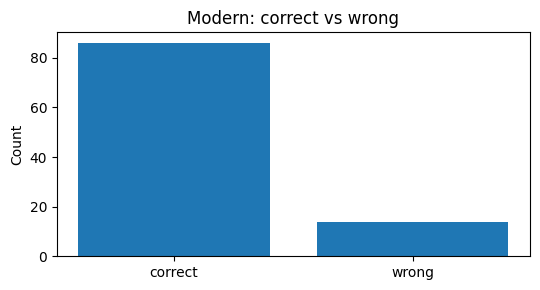

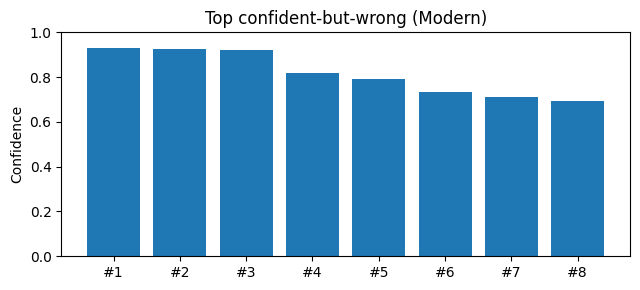

Top 8 confident-but-wrong:

------------------------------------------------------------
#1 conf=0.929
TRUE: 19 talk.religion.misc
PRED: 15 soc.religion.christian
text: Do you consider meditating equivalent to praying? I'm genuinely curious. I was talking to my cousin today and I told her that I think meditating and praying are kind of the same thing but she disagrees. I'm spiritual so when I meditate I feel like it's me talking to myself & the universe. When a Christian person is praying they are talking to God right? Isn't that similar in a way? But then what if you're not spiritu ...

------------------------------------------------------------
#2 conf=0.927
TRUE:  5 comp.windows.x
PRED:  2 comp.os.ms-windows.misc
text: I have 50 FPS difference between Linux and Windows, what gives? Help Request Edit: Problem found, reverted the nvidia driver to the november 2025 version, 581 I think. Flatscreen fps in windows 11 jumped from 50 to 70, vr fps jumped from max 22 to stable 36. 36fps+AS

In [249]:
#Confident-but-wrong (unique)
probs = F.softmax(all_logits, dim=1)
wrong = (preds != all_labels)
wrong_idx = torch.where(wrong)[0]

print("Wrong:", int(wrong.sum().item()), "/", int(all_labels.shape[0]))

plt.figure(figsize=(5.5, 3))
plt.title("Modern: correct vs wrong")
plt.bar(["correct", "wrong"], [int((~wrong).sum().item()), int(wrong.sum().item())])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

TOP_N = 8
if len(wrong_idx) > 0:
    conf_wrong = probs[wrong_idx, preds[wrong_idx]]
    rank = torch.argsort(conf_wrong, descending=True)

    seen = set()
    chosen = []
    for j in rank.tolist():
        i = int(wrong_idx[j].item())
        key = all_clean[i].strip().lower()
        if key in seen:
            continue
        seen.add(key)
        chosen.append(i)
        if len(chosen) >= TOP_N:
            break

    confs = [float(probs[i, int(preds[i].item())].item()) for i in chosen]
    plt.figure(figsize=(6.5, 3))
    plt.title("Top confident-but-wrong (Modern)")
    plt.bar([f"#{i+1}" for i in range(len(confs))], confs)
    plt.ylim(0, 1)
    plt.ylabel("Confidence")
    plt.tight_layout()
    plt.show()

    print(f"Top {len(chosen)} confident-but-wrong:")
    for r, i in enumerate(chosen, 1):
        t = int(all_labels[i].item())
        p = int(preds[i].item())
        c = float(probs[i, p].item())
        print("\n" + "-" * 60)
        print(f"#{r} conf={c:.3f}")
        print("TRUE:", f"{t:2d}", label_names[t])
        print("PRED:", f"{p:2d}", label_names[p])
        print("text:", all_clean[i][:420].replace("\n", " "), "...")
else:
    print("No wrong examples to show.")

# SECTION 9 — Confidence + Temperature Scaling (Calibration)


SECTION 9 — Calibration
Device      : cuda
NUM_CLASSES : 20
Loaded BEST checkpoint -> model.eval()


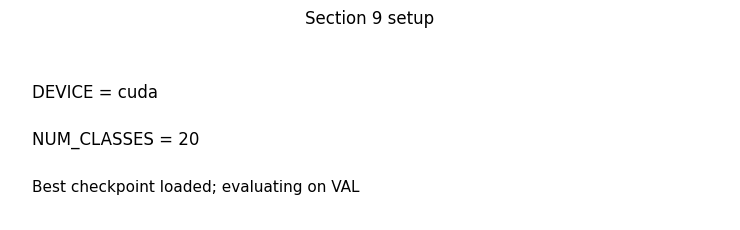

In [250]:
#Safety checks + load BEST checkpoint
if "model" not in globals():
    raise RuntimeError("Missing `model`. Run Section 5/6 first.")
if "val_loader" not in globals():
    raise RuntimeError("Missing `val_loader`. Run Section 4 first.")
if "DEVICE" not in globals():
    raise RuntimeError("Missing `DEVICE`. Run Section 1 first.")
if "id2label" not in globals():
    raise RuntimeError("Missing `id2label`. Run Section 2 first.")

if "best_state_dict" in globals():
    BEST = best_state_dict
elif "best_state" in globals():
    BEST = best_state
else:
    raise RuntimeError("Missing best checkpoint (`best_state_dict` or `best_state`). Run Section 6 first.")

NUM_CLASSES = len(id2label)

print("SECTION 9 — Calibration")
print("Device      :", DEVICE)
print("NUM_CLASSES :", NUM_CLASSES)

model.load_state_dict(BEST)
model.to(DEVICE)
model.eval()
print("Loaded BEST checkpoint -> model.eval()")

plt.figure(figsize=(7.5, 2.4))
plt.title("Section 9 setup")
plt.text(0.03, 0.65, f"DEVICE = {DEVICE}", fontsize=12)
plt.text(0.03, 0.40, f"NUM_CLASSES = {NUM_CLASSES}", fontsize=12)
plt.text(0.03, 0.15, "Best checkpoint loaded; evaluating on VAL", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()

VAL logits: (1648, 20) | VAL labels: (1648,)


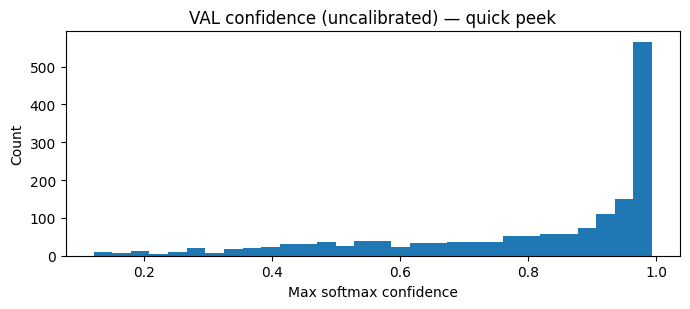

In [251]:
#Collect VAL logits + labels
@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    all_logits = []
    all_labels = []
    for batch in loader:
        x = batch["input_ids"].to(device)
        m = batch["attention_mask"].to(device)
        y = batch["labels"].to(device)

        logits = model(x, m)
        all_logits.append(logits.detach().cpu())
        all_labels.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return logits, labels

val_logits, val_labels = collect_logits_and_labels(model, val_loader, DEVICE)
print("VAL logits:", tuple(val_logits.shape), "| VAL labels:", tuple(val_labels.shape))

# visual: confidence histogram (uncalibrated) quick peek
with torch.no_grad():
    probs = F.softmax(val_logits, dim=1)
    conf, _ = probs.max(dim=1)

plt.figure(figsize=(7, 3.2))
plt.title("VAL confidence (uncalibrated) — quick peek")
plt.hist(conf.numpy(), bins=30)
plt.xlabel("Max softmax confidence")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

VAL — Uncalibrated
  Accuracy: 0.7439
  NLL     : 0.8521
  ECE     : 0.0610


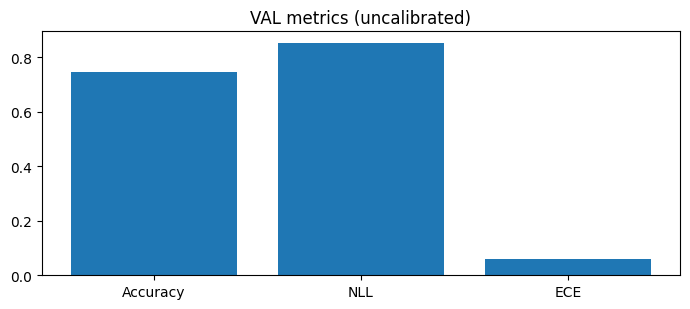

In [252]:
#Metrics (acc / NLL / ECE) + uncalibrated report
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return float((preds == labels).float().mean().item())

def nll_from_logits(logits, labels):
    return float(nn.CrossEntropyLoss()(logits, labels).item())

def ece_from_logits(logits, labels, bins=15):
    probs = F.softmax(logits, dim=1)
    conf, preds = probs.max(dim=1)
    correct = (preds == labels).float()

    conf = conf.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy()

    edges = np.linspace(0.0, 1.0, bins + 1)
    n = len(conf)

    ece = 0.0
    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]
        if i < bins - 1:
            mask = (conf >= lo) & (conf < hi)
        else:
            mask = (conf >= lo) & (conf <= hi)

        k = int(mask.sum())
        if k == 0:
            continue

        avg_conf = float(conf[mask].mean())
        avg_acc = float(correct[mask].mean())
        ece += (k / n) * abs(avg_conf - avg_acc)

    return float(ece)

val_acc_uncal = accuracy_from_logits(val_logits, val_labels)
val_nll_uncal = nll_from_logits(val_logits, val_labels)
val_ece_uncal = ece_from_logits(val_logits, val_labels, bins=15)

print("VAL — Uncalibrated")
print("  Accuracy:", f"{val_acc_uncal:.4f}")
print("  NLL     :", f"{val_nll_uncal:.4f}")
print("  ECE     :", f"{val_ece_uncal:.4f}")

# visual: metrics bar chart
plt.figure(figsize=(7, 3.2))
plt.title("VAL metrics (uncalibrated)")
plt.bar(["Accuracy", "NLL", "ECE"], [val_acc_uncal, val_nll_uncal, val_ece_uncal])
plt.tight_layout()
plt.show()

Learned temperature T: 1.1070


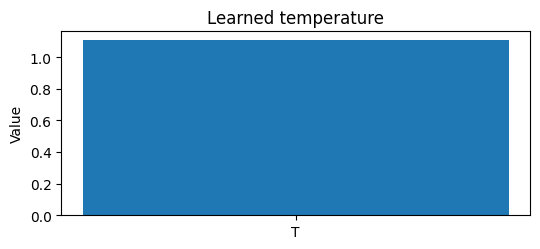

In [253]:
#Temperature scaling (fit T on VAL)
class TemperatureScaler(nn.Module):
    """
    logits_cal = logits / T   with T > 0
    We optimize log_T for stability.
    """
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        T = torch.exp(self.log_T)
        return logits / T

    def temperature(self):
        return float(torch.exp(self.log_T).item())

def fit_temperature(val_logits_cpu, val_labels_cpu, device):
    scaler = TemperatureScaler().to(device)

    logits = val_logits_cpu.to(device)
    labels = val_labels_cpu.to(device)

    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.LBFGS([scaler.log_T], lr=0.1, max_iter=200)

    def closure():
        opt.zero_grad(set_to_none=True)
        loss = loss_fn(scaler(logits), labels)
        loss.backward()
        return loss

    opt.step(closure)
    return scaler

temp_scaler = fit_temperature(val_logits, val_labels, DEVICE)
T = temp_scaler.temperature()

print("Learned temperature T:", f"{T:.4f}")

plt.figure(figsize=(5.5, 2.6))
plt.title("Learned temperature")
plt.bar(["T"], [T])
plt.ylabel("Value")
plt.tight_layout()
plt.show()

VAL — Calibrated
  Accuracy: 0.7439
  NLL     : 0.8444
  ECE     : 0.0360


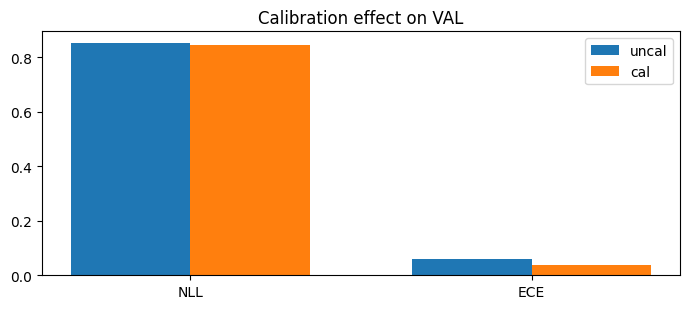

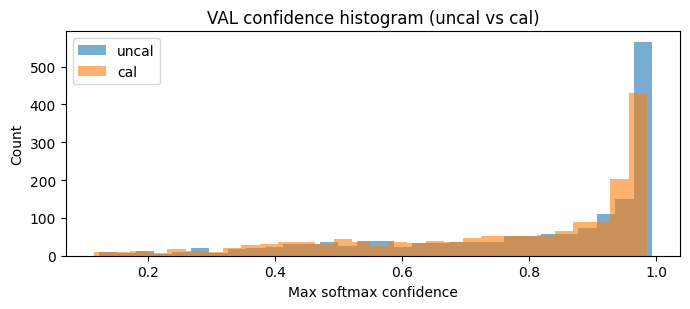

In [254]:
#Calibrated VAL metrics + before/after
with torch.no_grad():
    val_logits_cal = temp_scaler(val_logits.to(DEVICE)).cpu()

val_acc_cal = accuracy_from_logits(val_logits_cal, val_labels)
val_nll_cal = nll_from_logits(val_logits_cal, val_labels)
val_ece_cal = ece_from_logits(val_logits_cal, val_labels, bins=15)

print("VAL — Calibrated")
print("  Accuracy:", f"{val_acc_cal:.4f}")
print("  NLL     :", f"{val_nll_cal:.4f}")
print("  ECE     :", f"{val_ece_cal:.4f}")

# visual: compare uncal vs cal (NLL, ECE)
plt.figure(figsize=(7, 3.2))
plt.title("Calibration effect on VAL")
x = np.arange(2)
w = 0.35
plt.bar(x - w/2, [val_nll_uncal, val_ece_uncal], w, label="uncal")
plt.bar(x + w/2, [val_nll_cal,   val_ece_cal],   w, label="cal")
plt.xticks(x, ["NLL", "ECE"])
plt.legend()
plt.tight_layout()
plt.show()

# visual: confidence hist before vs after
with torch.no_grad():
    conf_uncal = F.softmax(val_logits, dim=1).max(dim=1).values.numpy()
    conf_cal   = F.softmax(val_logits_cal, dim=1).max(dim=1).values.numpy()

plt.figure(figsize=(7, 3.2))
plt.title("VAL confidence histogram (uncal vs cal)")
plt.hist(conf_uncal, bins=30, alpha=0.6, label="uncal")
plt.hist(conf_cal,   bins=30, alpha=0.6, label="cal")
plt.xlabel("Max softmax confidence")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

SECTION 9 — Reliability plots (VAL)


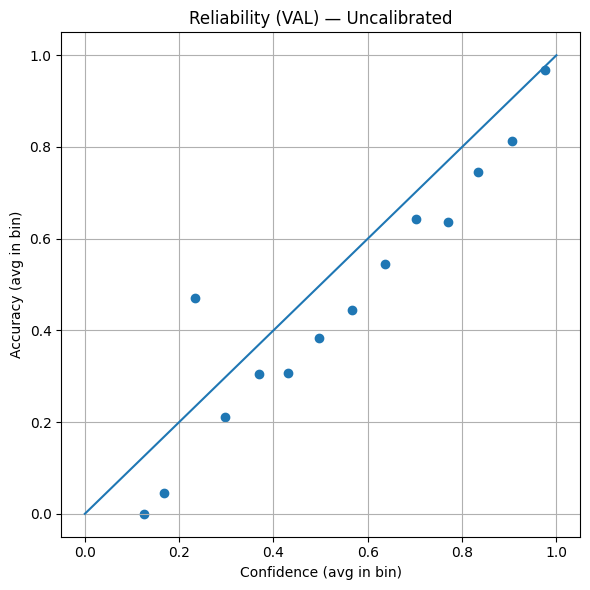

Reliability (VAL) — Uncalibrated | non-empty bins: 14/15 | bin counts: [0, 3, 22, 17, 33, 46, 65, 81, 81, 68, 84, 99, 137, 187, 725]


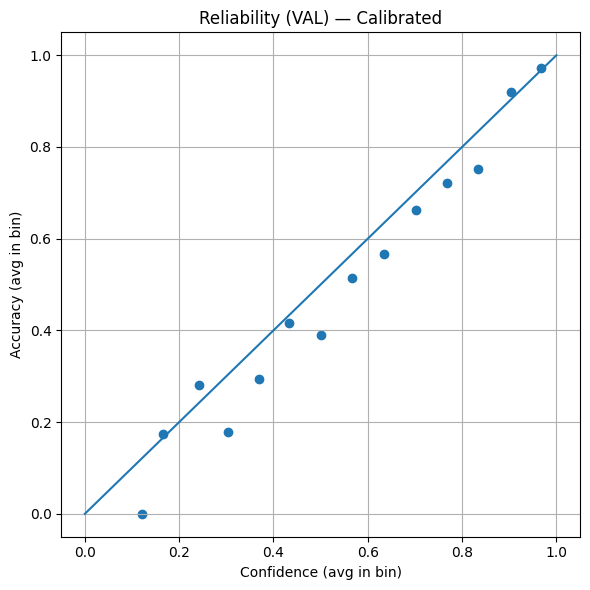

Reliability (VAL) — Calibrated | non-empty bins: 14/15 | bin counts: [0, 7, 23, 32, 28, 68, 77, 87, 72, 83, 95, 122, 133, 226, 595]


In [255]:
#Reliability graph (uncal + cal)
def plot_reliability(logits, labels, title, bins=15):
    probs = F.softmax(logits, dim=1)
    conf, preds = probs.max(dim=1)
    correct = (preds == labels).float()

    conf = conf.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy()

    edges = np.linspace(0.0, 1.0, bins + 1)

    xs, ys, counts = [], [], []
    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]
        if i < bins - 1:
            mask = (conf >= lo) & (conf < hi)
        else:
            mask = (conf >= lo) & (conf <= hi)

        n = int(mask.sum())
        counts.append(n)

        if n == 0:
            xs.append(np.nan)
            ys.append(np.nan)
            continue

        xs.append(float(conf[mask].mean()))
        ys.append(float(correct[mask].mean()))

    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1])
    ok = np.isfinite(xs) & np.isfinite(ys)
    plt.scatter(xs[ok], ys[ok])
    plt.title(title)
    plt.xlabel("Confidence (avg in bin)")
    plt.ylabel("Accuracy (avg in bin)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{title} | non-empty bins: {int(ok.sum())}/{bins} | bin counts:", counts)

print("SECTION 9 — Reliability plots (VAL)")
plot_reliability(val_logits, val_labels, "Reliability (VAL) — Uncalibrated", bins=15)
plot_reliability(val_logits_cal, val_labels, "Reliability (VAL) — Calibrated", bins=15)

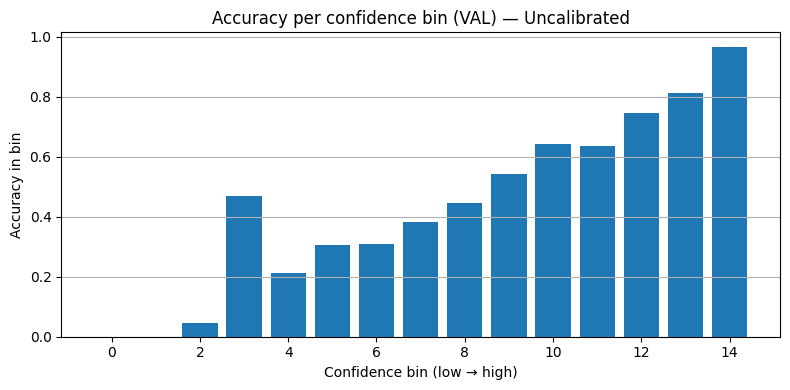

Accuracy per confidence bin (VAL) — Uncalibrated | bin counts: [0, 3, 22, 17, 33, 46, 65, 81, 81, 68, 84, 99, 137, 187, 725]


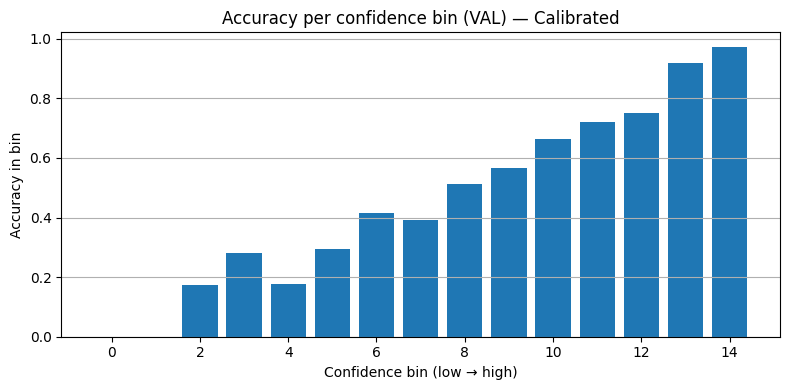

Accuracy per confidence bin (VAL) — Calibrated | bin counts: [0, 7, 23, 32, 28, 68, 77, 87, 72, 83, 95, 122, 133, 226, 595]


In [256]:
#Accuracy per confidence bin (uncal + cal)
def plot_acc_per_bin(logits, labels, title, bins=15):
    probs = F.softmax(logits, dim=1)
    conf, preds = probs.max(dim=1)
    correct = (preds == labels).float()

    conf = conf.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy()

    edges = np.linspace(0.0, 1.0, bins + 1)

    accs = []
    counts = []
    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]
        if i < bins - 1:
            mask = (conf >= lo) & (conf < hi)
        else:
            mask = (conf >= lo) & (conf <= hi)

        n = int(mask.sum())
        counts.append(n)

        if n == 0:
            accs.append(np.nan)
        else:
            accs.append(float(correct[mask].mean()))

    accs = np.array(accs, dtype=float)

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(bins), np.nan_to_num(accs, nan=0.0))
    plt.title(title)
    plt.xlabel("Confidence bin (low → high)")
    plt.ylabel("Accuracy in bin")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    print(title, "| bin counts:", counts)

plot_acc_per_bin(val_logits, val_labels, "Accuracy per confidence bin (VAL) — Uncalibrated", bins=15)
plot_acc_per_bin(val_logits_cal, val_labels, "Accuracy per confidence bin (VAL) — Calibrated", bins=15)

Example confidence values (first 10):
  Uncal: [0.16330596804618835, 0.5554779767990112, 0.13576941192150116, 0.20462290942668915, 0.29263752698898315, 0.4209845960140228, 0.12481094896793365, 0.7686192393302917, 0.6444519758224487, 0.20311950147151947]
  Cal  : [0.1473141610622406, 0.5015366673469543, 0.12476512044668198, 0.18439891934394836, 0.25913184881210327, 0.36831149458885193, 0.1166895180940628, 0.7110244631767273, 0.5845576524734497, 0.18286944925785065]


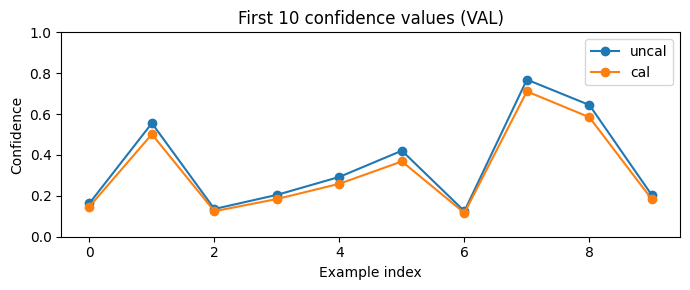

In [257]:
#Final confidence function + example values
def confidence_score(logits, scaler=None):
    """
    Returns max softmax probability per sample.
    If scaler is provided, applies temperature scaling first.
    """
    if scaler is not None:
        with torch.no_grad():
            logits = scaler(logits.to(DEVICE)).cpu()

    probs = F.softmax(logits, dim=1)
    conf, _ = probs.max(dim=1)
    return conf

unc = confidence_score(val_logits)[:10].tolist()
cal = confidence_score(val_logits, temp_scaler)[:10].tolist()

print("Example confidence values (first 10):")
print("  Uncal:", unc)
print("  Cal  :", cal)

plt.figure(figsize=(7, 3))
plt.title("First 10 confidence values (VAL)")
plt.plot(unc, marker="o", label="uncal")
plt.plot(cal, marker="o", label="cal")
plt.ylim(0, 1)
plt.xlabel("Example index")
plt.ylabel("Confidence")
plt.legend()
plt.tight_layout()
plt.show()

TEST — Calibration report (T fit on VAL only)
  NLL (uncal): 0.9626
  ECE (uncal): 0.0712
  NLL (cal)  : 0.9479
  ECE (cal)  : 0.0408


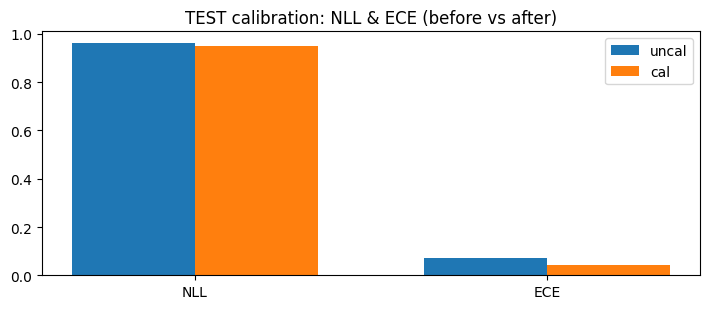

In [258]:
#Calibration report on TEST (no refitting)
if "test_loader" in globals():
    test_logits, test_labels = collect_logits_and_labels(model, test_loader, DEVICE)

    test_nll_uncal = nll_from_logits(test_logits, test_labels)
    test_ece_uncal = ece_from_logits(test_logits, test_labels, bins=15)

    with torch.no_grad():
        test_logits_cal = temp_scaler(test_logits.to(DEVICE)).cpu()

    test_nll_cal = nll_from_logits(test_logits_cal, test_labels)
    test_ece_cal = ece_from_logits(test_logits_cal, test_labels, bins=15)

    print("TEST — Calibration report (T fit on VAL only)")
    print("  NLL (uncal):", f"{test_nll_uncal:.4f}")
    print("  ECE (uncal):", f"{test_ece_uncal:.4f}")
    print("  NLL (cal)  :", f"{test_nll_cal:.4f}")
    print("  ECE (cal)  :", f"{test_ece_cal:.4f}")

    plt.figure(figsize=(7.2, 3.2))
    plt.title("TEST calibration: NLL & ECE (before vs after)")
    x = np.arange(2)
    w = 0.35
    plt.bar(x - w/2, [test_nll_uncal, test_ece_uncal], w, label="uncal")
    plt.bar(x + w/2, [test_nll_cal,   test_ece_cal],   w, label="cal")
    plt.xticks(x, ["NLL", "ECE"])
    plt.legend()
    plt.tight_layout()
    plt.show()

# "OTHER" without OOD (selective prediction)


Section 10 ready.
  device: cuda
  classes: 20
  has temp_scaler: True


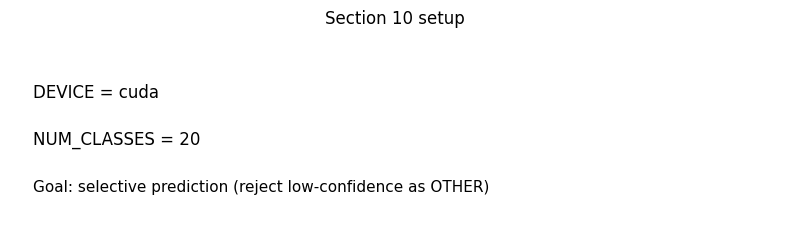

In [259]:
#Checks + load BEST
need = ["model", "DEVICE", "val_loader", "temp_scaler"]
for k in need:
    if k not in globals():
        raise RuntimeError(f"Missing `{k}`. Run earlier sections first.")

if "best_state_dict" in globals():
    BEST = best_state_dict
elif "best_state" in globals():
    BEST = best_state
else:
    raise RuntimeError("Missing best checkpoint (best_state_dict or best_state). Run Section 6.")

if "NUM_CLASSES" not in globals():
    if "id2label" not in globals():
        raise RuntimeError("Need NUM_CLASSES or id2label.")
    NUM_CLASSES = len(id2label)

print("Section 10 ready.")
print("  device:", DEVICE)
print("  classes:", NUM_CLASSES)
print("  has temp_scaler:", True)

model.load_state_dict(BEST)
model.to(DEVICE)
model.eval()

plt.figure(figsize=(8, 2.4))
plt.title("Section 10 setup")
plt.text(0.03, 0.65, f"DEVICE = {DEVICE}", fontsize=12)
plt.text(0.03, 0.40, f"NUM_CLASSES = {NUM_CLASSES}", fontsize=12)
plt.text(0.03, 0.15, "Goal: selective prediction (reject low-confidence as OTHER)", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()

  val logits: (1648, 20)
  val labels: (1648,)


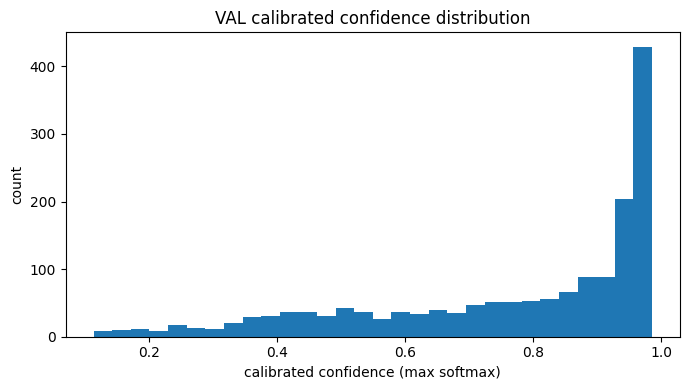

In [260]:
#Collect VAL logits/labels + quick confidence histogram (calibrated)
@torch.no_grad()
def collect_logits_labels(model, loader):
    logits_list, labels_list = [], []
    for batch in loader:
        x = batch["input_ids"].to(DEVICE)
        m = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        logits = model(x, m)
        logits_list.append(logits.cpu())
        labels_list.append(y.cpu())

    return torch.cat(logits_list, dim=0), torch.cat(labels_list, dim=0)


print("Collecting VAL logits for threshold sweep...")
val_logits, val_labels = collect_logits_labels(model, val_loader)
print("  val logits:", tuple(val_logits.shape))
print("  val labels:", tuple(val_labels.shape))

@torch.no_grad()
def calibrated_conf_and_pred(logits):
    logits_cal = temp_scaler(logits.to(DEVICE)).cpu()
    probs = F.softmax(logits_cal, dim=1)
    conf, pred = probs.max(dim=1)
    return conf, pred

val_conf, _ = calibrated_conf_and_pred(val_logits)

plt.figure(figsize=(7, 4))
plt.title("VAL calibrated confidence distribution")
plt.hist(val_conf.numpy(), bins=30)
plt.xlabel("calibrated confidence (max softmax)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [261]:
#Macro-F1 on subset + selective metrics function
def macro_f1_on_subset(pred_np, y_np, C):
    cm = np.zeros((C, C), dtype=np.int64)
    for t, p in zip(y_np, pred_np):
        cm[int(t), int(p)] += 1

    row_sum = cm.sum(axis=1)
    col_sum = cm.sum(axis=0)

    f1s = []
    for c in range(C):
        tp = cm[c, c]
        fp = col_sum[c] - tp
        fn = row_sum[c] - tp

        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
        f1s.append(f1)

    return float(np.mean(f1s))

@torch.no_grad()
def selective_metrics(logits, labels, tau):
    conf, pred = calibrated_conf_and_pred(logits)
    accepted = conf >= float(tau)

    total = int(labels.numel())
    accepted_n = int(accepted.sum().item())

    coverage = accepted_n / total
    reject_rate = 1.0 - coverage

    if accepted_n == 0:
        sel_acc = float("nan")
        sel_f1 = float("nan")
        mean_conf_acc = float("nan")
    else:
        sel_acc = float((pred[accepted] == labels[accepted]).float().mean().item())
        sel_f1 = macro_f1_on_subset(
            pred[accepted].numpy(),
            labels[accepted].numpy(),
            NUM_CLASSES
        )
        mean_conf_acc = float(conf[accepted].mean().item())

    mean_conf_rej = float(conf[~accepted].mean().item()) if accepted_n < total else float("nan")

    return {
        "tau": float(tau),
        "coverage": float(coverage),
        "reject_rate": float(reject_rate),
        "accepted": accepted_n,
        "total": total,
        "sel_acc": float(sel_acc),
        "sel_macro_f1": float(sel_f1),
        "mean_conf_acc": float(mean_conf_acc),
        "mean_conf_rej": float(mean_conf_rej),
    }

Sweep finished.
As tau goes up: coverage usually goes down, selective accuracy usually goes up.


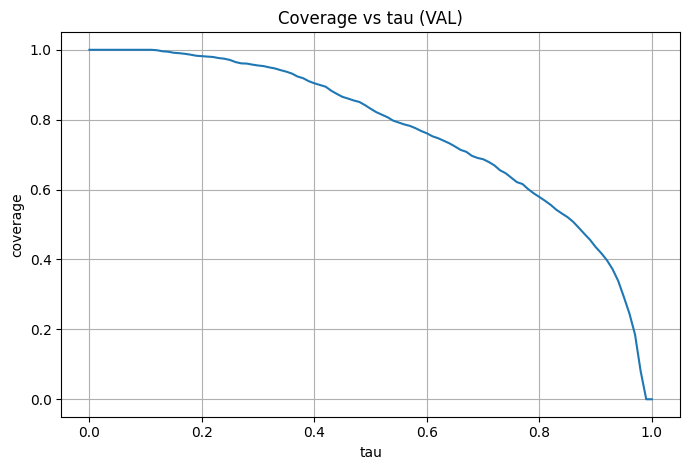

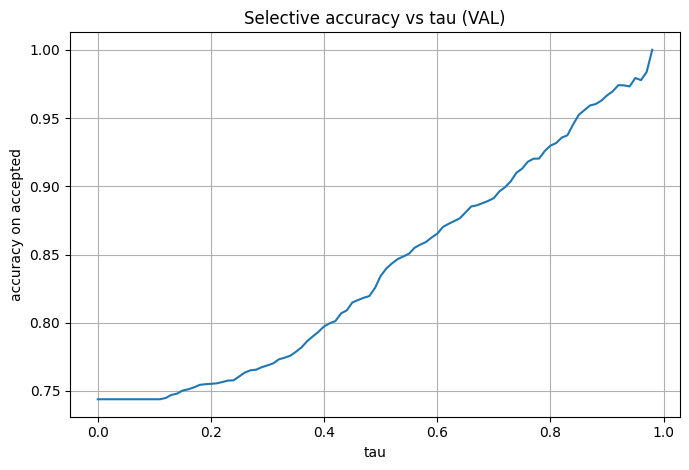

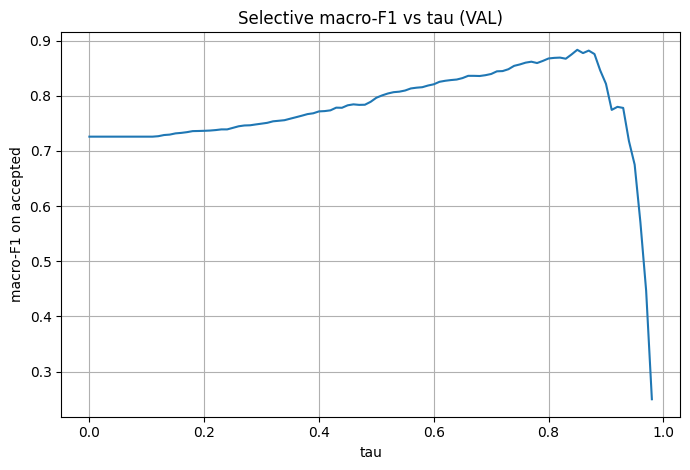

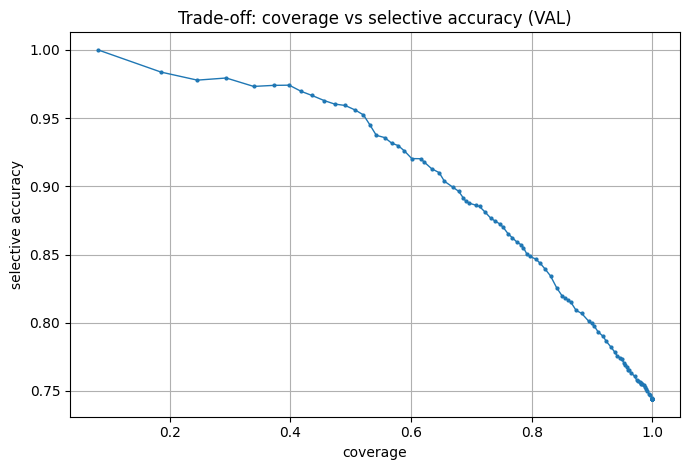

In [262]:
#Sweep tau on VAL + visualize curves
taus = np.linspace(0.0, 1.0, 101)
rows = [selective_metrics(val_logits, val_labels, t) for t in taus]

cov = np.array([r["coverage"] for r in rows], dtype=float)
sel_acc = np.array([r["sel_acc"] for r in rows], dtype=float)
sel_f1 = np.array([r["sel_macro_f1"] for r in rows], dtype=float)

print("Sweep finished.")
print("As tau goes up: coverage usually goes down, selective accuracy usually goes up.")

taus_np = np.asarray(taus, dtype=float)
mask_acc = np.isfinite(sel_acc)
mask_f1  = np.isfinite(sel_f1)

plt.figure(figsize=(7, 4.8))
plt.title("Coverage vs tau (VAL)")
plt.plot(taus_np, cov)
plt.xlabel("tau")
plt.ylabel("coverage")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.title("Selective accuracy vs tau (VAL)")
plt.plot(taus_np[mask_acc], sel_acc[mask_acc])
plt.xlabel("tau")
plt.ylabel("accuracy on accepted")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.title("Selective macro-F1 vs tau (VAL)")
plt.plot(taus_np[mask_f1], sel_f1[mask_f1])
plt.xlabel("tau")
plt.ylabel("macro-F1 on accepted")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.title("Trade-off: coverage vs selective accuracy (VAL)")
plt.plot(cov[mask_acc], sel_acc[mask_acc], marker="o", markersize=2, linewidth=1)
plt.xlabel("coverage")
plt.ylabel("selective accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

Chosen operating points (VAL only):
  conservative tau = 0.850  (aim: sel_acc >= 0.95)
  liberal      tau = 0.530  (aim: coverage >= 0.80)


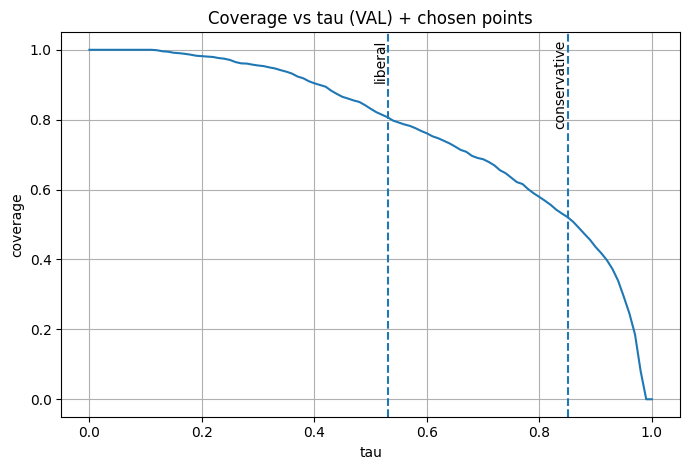

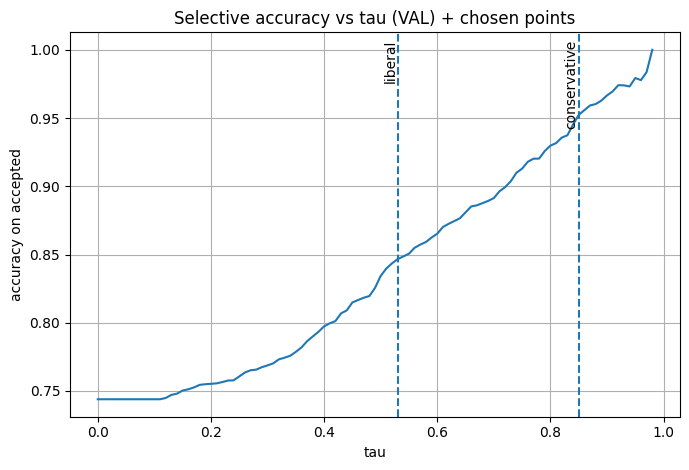

In [263]:
#2 operating points (conservative + liberal)
target_sel_acc = 0.95   # conservative: "when I answer, be very right"
target_cov = 0.80       # liberal: "answer most of the time"

tau_conservative = None
for r in rows:
    if np.isfinite(r["sel_acc"]) and r["sel_acc"] >= target_sel_acc:
        tau_conservative = r["tau"]
        break
if tau_conservative is None:
    tau_conservative = float(taus_np[np.nanargmax(sel_acc)])

tau_liberal = None
for r in rows[::-1]:
    if r["coverage"] >= target_cov:
        tau_liberal = r["tau"]
        break
if tau_liberal is None:
    tau_liberal = 0.0

print("Chosen operating points (VAL only):")
print(f"  conservative tau = {tau_conservative:.3f}  (aim: sel_acc >= {target_sel_acc:.2f})")
print(f"  liberal      tau = {tau_liberal:.3f}  (aim: coverage >= {target_cov:.2f})")

def add_vline(ax, x, label):
    ax.axvline(x, linestyle="--")
    ax.text(x, 0.98, label, rotation=90, va="top", ha="right",
            transform=ax.get_xaxis_transform())

plt.figure(figsize=(7, 4.8))
plt.title("Coverage vs tau (VAL) + chosen points")
plt.plot(taus_np, cov)
plt.xlabel("tau"); plt.ylabel("coverage")
plt.grid(True)
add_vline(plt.gca(), tau_conservative, "conservative")
add_vline(plt.gca(), tau_liberal, "liberal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.title("Selective accuracy vs tau (VAL) + chosen points")
plt.plot(taus_np[mask_acc], sel_acc[mask_acc])
plt.xlabel("tau"); plt.ylabel("accuracy on accepted")
plt.grid(True)
add_vline(plt.gca(), tau_conservative, "conservative")
add_vline(plt.gca(), tau_liberal, "liberal")
plt.tight_layout()
plt.show()


------------------------------------------------------------
VAL conservative | tau = 0.850
  coverage          : 0.521 (859/1648)
  reject_rate       : 0.479
  sel_acc           : 0.952
  sel_macro_f1      : 0.883
  mean_conf_accepted: 0.945
  mean_conf_rejected: 0.577

------------------------------------------------------------
VAL liberal | tau = 0.530
  coverage          : 0.807 (1330/1648)
  reject_rate       : 0.193
  sel_acc           : 0.847
  sel_macro_f1      : 0.806
  mean_conf_accepted: 0.861
  mean_conf_rejected: 0.380


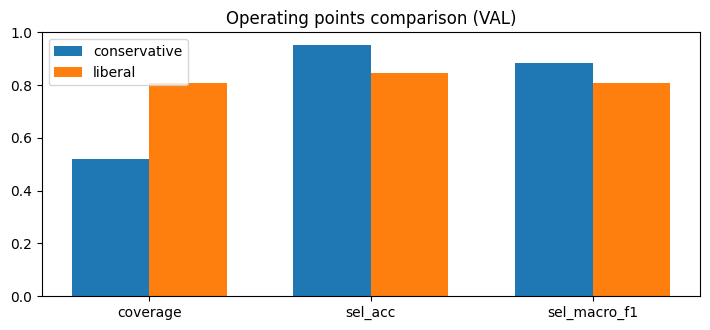

In [264]:
#Print final VAL numbers at chosen taus
def print_point(title, tau):
    r = selective_metrics(val_logits, val_labels, tau)
    print("\n" + "-" * 60)
    print(title, "| tau =", f"{tau:.3f}")
    print("  coverage          :", f"{r['coverage']:.3f}", f"({r['accepted']}/{r['total']})")
    print("  reject_rate       :", f"{r['reject_rate']:.3f}")
    print("  sel_acc           :", f"{r['sel_acc']:.3f}")
    print("  sel_macro_f1      :", f"{r['sel_macro_f1']:.3f}")
    print("  mean_conf_accepted:", f"{r['mean_conf_acc']:.3f}")
    print("  mean_conf_rejected:", f"{r['mean_conf_rej']:.3f}")
    return r

r_cons = print_point("VAL conservative", tau_conservative)
r_lib  = print_point("VAL liberal", tau_liberal)

# visual: compare the two operating points
plt.figure(figsize=(7.2, 3.4))
plt.title("Operating points comparison (VAL)")
labels = ["coverage", "sel_acc", "sel_macro_f1"]
cons_vals = [r_cons["coverage"], r_cons["sel_acc"], r_cons["sel_macro_f1"]]
lib_vals  = [r_lib["coverage"],  r_lib["sel_acc"],  r_lib["sel_macro_f1"]]

x = np.arange(len(labels))
w = 0.35
plt.bar(x - w/2, cons_vals, w, label="conservative")
plt.bar(x + w/2, lib_vals,  w, label="liberal")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


------------------------------------------------------------
TEST conservative (fixed tau from VAL) | tau = 0.850
  coverage     : 0.497 (3635/7317)
  reject_rate  : 0.503
  sel_acc      : 0.929
  sel_macro_f1 : 0.859

------------------------------------------------------------
TEST liberal (fixed tau from VAL) | tau = 0.530
  coverage     : 0.787 (5762/7317)
  reject_rate  : 0.213
  sel_acc      : 0.822
  sel_macro_f1 : 0.781


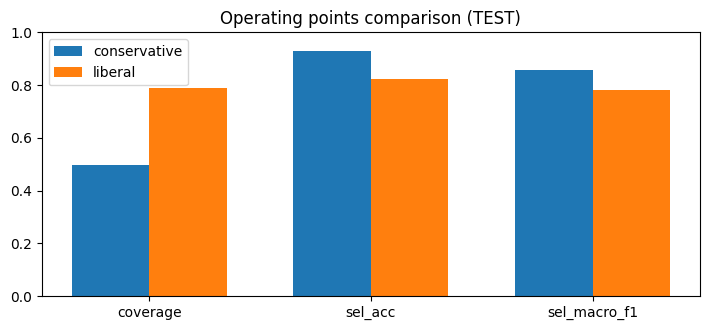

In [265]:
#TEST report using fixed taus (no tuning)
if "test_loader" in globals():
    print("Collecting TEST logits (report only)...")
    test_logits, test_labels = collect_logits_labels(model, test_loader)

    def print_test(title, tau):
        r = selective_metrics(test_logits, test_labels, tau)
        print("\n" + "-" * 60)
        print(title, "| tau =", f"{tau:.3f}")
        print("  coverage     :", f"{r['coverage']:.3f}", f"({r['accepted']}/{r['total']})")
        print("  reject_rate  :", f"{r['reject_rate']:.3f}")
        print("  sel_acc      :", f"{r['sel_acc']:.3f}")
        print("  sel_macro_f1 :", f"{r['sel_macro_f1']:.3f}")
        return r

    t_cons = print_test("TEST conservative (fixed tau from VAL)", tau_conservative)
    t_lib  = print_test("TEST liberal (fixed tau from VAL)", tau_liberal)

    # visual: compare on TEST
    plt.figure(figsize=(7.2, 3.4))
    plt.title("Operating points comparison (TEST)")
    labels = ["coverage", "sel_acc", "sel_macro_f1"]
    cons_vals = [t_cons["coverage"], t_cons["sel_acc"], t_cons["sel_macro_f1"]]
    lib_vals  = [t_lib["coverage"],  t_lib["sel_acc"],  t_lib["sel_macro_f1"]]

    x = np.arange(len(labels))
    w = 0.35
    plt.bar(x - w/2, cons_vals, w, label="conservative")
    plt.bar(x + w/2, lib_vals,  w, label="liberal")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()